# SQR Speed-Limit With Multitone Gaussian Pulses

This notebook reproduces the `SQR + ideal fast pi` baseline and the general-SQR duration sweep implemented in `cqed_sim.analysis.sqr_speedlimit_multitone_gaussian`.

Conventions used here:
- Main sweep: minimal dispersive qubit-drive-only model with `chi = -2.84 MHz`.
- Phase 1 tested gate: `U_test = U_pi,ideal @ U_SQR`.
- The unconditional fast `pi` gate is treated as perfect in the main speed-limit claim.
- A separate `16 ns` pulse-level unconditional `pi` validation is included below.
- Photon number is conserved in the main sweep model, so literal subspace leakage is zero; the guard metric is a selectivity proxy on out-of-support manifolds.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

from cqed_sim.analysis.sqr_speedlimit_multitone_gaussian import (
    SQRSpeedLimitConfig,
    build_default_target_cases,
    run_speedlimit_study,
    run_speedlimit_sweep_point,
)
from cqed_sim.unitary_synthesis.progress import JupyterLiveReporter, plot_history

SEED = 1234
OUTPUT_DIR = Path('outputs/analysis/sqr_speedlimit_multitone_gaussian/seed_1234')


In [2]:
study = SQRSpeedLimitConfig(
    seed=SEED,
    multistart=1,
    optimizer_maxiter_stage1=3,
    optimizer_maxiter_stage2=4,
    fast_pi_multistart=4,
    dt_s=1e-9,
    n_match=3
)

print(study)
print(f'Output directory: {study.output_dir()}')


SQRSpeedLimitConfig(seed=1234, n_match=3, guard_levels=1, chi_hz=-2840000.0, chi2_hz=0.0, chi3_hz=0.0, kerr_hz=0.0, omega_q_hz=0.0, omega_c_hz=0.0, qubit_alpha_hz=0.0, durations_ns=(50, 75, 100, 150, 200, 300, 500, 750, 1000), sigma_fractions=(0.15, 0.2, 0.25, 0.3), multistart=1, dt_s=1e-09, max_step_s=2e-09, optimizer_maxiter_stage1=3, optimizer_maxiter_stage2=4, d_lambda_bounds=(-0.5, 0.5), d_alpha_bounds=(-3.141592653589793, 3.141592653589793), d_omega_hz_bounds=(-2000000.0, 2000000.0), lambda_guard=0.1, weight_mode='uniform', fidelity_thresholds=(0.99, 0.999, 0.9999), fast_pi_duration_s=1.6e-08, fast_pi_dt_s=2.5e-10, fast_pi_sigma_bounds=(0.12, 0.3), fast_pi_detuning_hz_bounds=(-6000000.0, 6000000.0), fast_pi_multistart=4, fast_pi_validate_levels=(1, 2), representative_duration_ns=200, output_root=WindowsPath('outputs/analysis/sqr_speedlimit_multitone_gaussian'), report_path=WindowsPath('cqed_sim/analysis/reports/sqr_speedlimit_report.md'), progress_every=1, qutip_nsteps_sqr_calibr

In [3]:
cases = build_default_target_cases(study)
phase1_case = cases['phase1'][0]
phase2_names = [case.name for case in cases['phase2']]
print('Phase 1 case:', phase1_case.name)
print('Phase 2 cases:', phase2_names)


Phase 1 case: phase1_selective_flip_n0
Phase 2 cases: ['phase2_alternating_flips', 'phase2_mixed_angles', 'phase2_seeded_random', 'phase2_cluster_like']


## Representative Progress Run

This runs one representative Phase-1 sweep point with a live progress reporter and keeps the recorded history for post-run plotting.


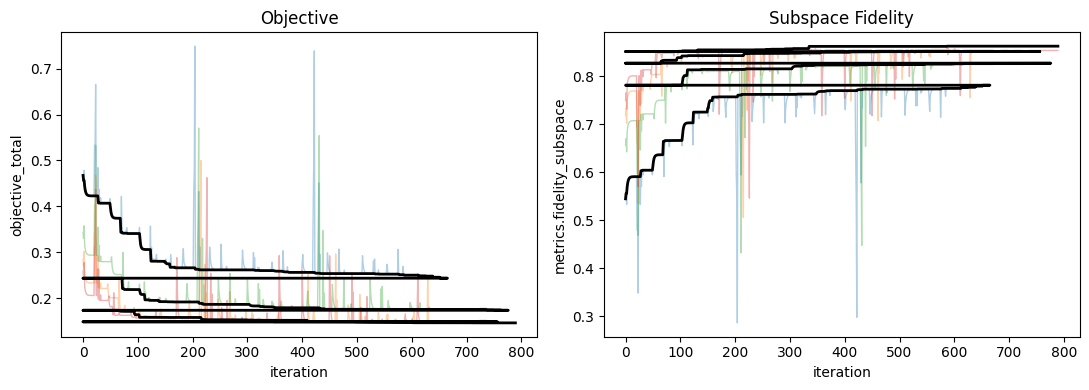

Representative fidelity: 0.9227100728965043
Representative sigma: 0.3
Representative run: phase1_selective_flip_n0_T0200ns_sigma0p3_start00


In [4]:
live_reporter = JupyterLiveReporter(what='objective_total', fidelity_what='metrics.fidelity_subspace', print_every=5)
representative_point = run_speedlimit_sweep_point(
    case=phase1_case,
    duration_s=study.representative_duration_ns * 1e-9,
    study=study,
    reporter=live_reporter,
    point_output_dir=OUTPUT_DIR / 'representative_live_point',
)

print('Representative fidelity:', representative_point['subspace_fidelity'])
print('Representative sigma:', representative_point['sigma_fraction'])
print('Representative run:', representative_point['selected_run_id'])


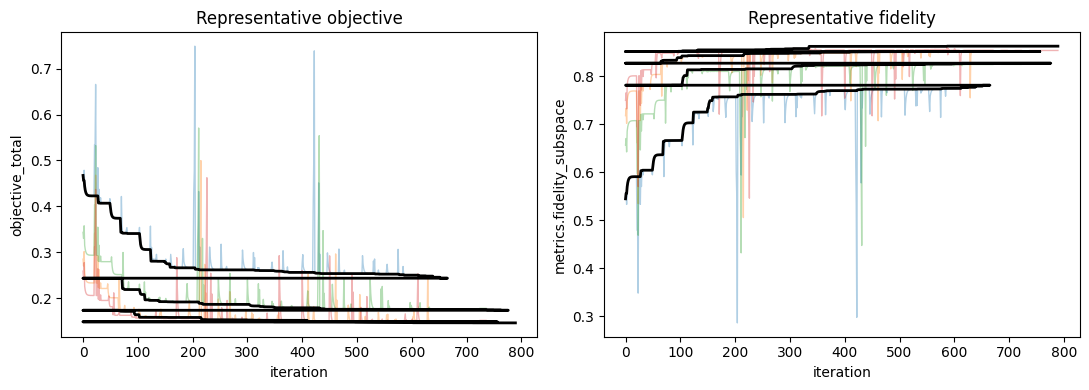

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_history(representative_point['history_by_run'], what='objective_total', ax=axes[0], title='Representative objective')
plot_history(representative_point['history_by_run'], what='metrics.fidelity_subspace', ax=axes[1], title='Representative fidelity')
fig.tight_layout()
plt.show()


## Full Study

This executes the full duration sweep used for the report and writes all artifacts to the deterministic output directory.


In [6]:
summary_path = OUTPUT_DIR / 'study_summary.json'
if summary_path.exists():
    summary = json.loads(summary_path.read_text(encoding='utf-8'))
    summary['report_path'] = str(Path(summary.get('report_path', study.report_path)))
else:
    summary = run_speedlimit_study(study)
print('Output dir:', summary['output_dir'])
print('Report path:', summary['report_path'])


Output dir: outputs\analysis\sqr_speedlimit_multitone_gaussian\seed_1234
Report path: cqed_sim\analysis\reports\sqr_speedlimit_report.md


In [7]:
display(Markdown(Path(summary['report_path']).read_text(encoding='utf-8')[:4000]))


# SQR Speed-Limit Report

## Study Definition
- Seed: `1234`
- Matched subspace: `n = 0..2` with `logical_n = 3`
- Guard levels: `1`
- Dispersive parameter: `chi = -2.840000 MHz`
- Phase-1 ordering convention: `U_test = U_pi,ideal @ U_SQR`, meaning the selective SQR acts first on the state and the ideal fast pi is applied after it.
- Leakage note: in the minimal dispersive qubit-drive-only model used for the main sweep, photon number is conserved, so subspace leakage for `n<=n_match` probe states is identically zero. The reported guard metric is therefore a selectivity proxy on out-of-support manifolds, not literal dynamical leakage.

## Phase 1
### phase1_selective_flip_n0
- Description: Selective pattern: only n=0 is flipped by the SQR. The tested gate is U_test = U_pi_ideal @ U_SQR.
  - `F >= 0.9900`: `750.0 ns`
  - `F >= 0.9990`: not reached
  - `F >= 0.9999`: not reached
- Best point: `T = 750.0 ns`, `sigma = 0.30`, `F_subspace = 0.991496`, `guard = 4.450e-02`

## Phase 2
### phase2_alternating_flips
- Description: Alternating selective flips across Fock levels.
  - `F >= 0.9900`: `500.0 ns`
  - `F >= 0.9990`: `500.0 ns`
  - `F >= 0.9999`: not reached

### phase2_mixed_angles
- Description: Mixed pi/2 and pi rotations with nontrivial XY phases.
  - `F >= 0.9900`: `500.0 ns`
  - `F >= 0.9990`: `1000.0 ns`
  - `F >= 0.9999`: not reached

### phase2_seeded_random
- Description: Deterministic seeded random target over the matched subspace.
  - `F >= 0.9900`: `500.0 ns`
  - `F >= 0.9990`: `1000.0 ns`
  - `F >= 0.9999`: not reached

### phase2_cluster_like
- Description: Cluster-relevant heuristic block pattern on n <= n_match.
  - `F >= 0.9900`: `500.0 ns`
  - `F >= 0.9990`: `1000.0 ns`
  - `F >= 0.9999`: not reached

## 16 ns Unconditional Pi Validation
- `n <= 1`: `F_subspace = 0.999679`, `worst block = 0.998728`, `detuning = -0.065 MHz`, `sigma = 0.120`
- `n <= 2`: `F_subspace = 0.998934`, `worst block = 0.994917`, `detuning = -0.129 MHz`, `sigma = 0.120`

## Configuration Snapshot
```json
{
  "seed": 1234,
  "n_match": 2,
  "guard_levels": 1,
  "chi_hz": -2840000.0,
  "chi2_hz": 0.0,
  "chi3_hz": 0.0,
  "kerr_hz": 0.0,
  "omega_q_hz": 0.0,
  "omega_c_hz": 0.0,
  "qubit_alpha_hz": 0.0,
  "durations_ns": [
    50,
    75,
    100,
    150,
    200,
    300,
    500,
    750,
    1000
  ],
  "sigma_fractions": [
    0.15,
    0.2,
    0.25,
    0.3
  ],
  "multistart": 1,
  "dt_s": 2e-09,
  "max_step_s": 2e-09,
  "optimizer_maxiter_stage1": 3,
  "optimizer_maxiter_stage2": 4,
  "d_lambda_bounds": [
    -0.5,
    0.5
  ],
  "d_alpha_bounds": [
    -3.141592653589793,
    3.141592653589793
  ],
  "d_omega_hz_bounds": [
    -2000000.0,
    2000000.0
  ],
  "lambda_guard": 0.1,
  "weight_mode": "uniform",
  "fidelity_thresholds": [
    0.99,
    0.999,
    0.9999
  ],
  "fast_pi_duration_s": 1.6e-08,
  "fast_pi_dt_s": 2.5e-10,
  "fast_pi_sigma_bounds": [
    0.12,
    0.3
  ],
  "fast_pi_detuning_hz_bounds": [
    -6000000.0,
    6000000.0
  ],
  "fast_pi_multistart": 4,
  "fast_pi_validate_levels": [
    1,
    2
  ],
  "representative_duration_ns": 200,
  "output_root": "outputs\\analysis\\sqr_speedlimit_multitone_gaussian",
  "report_path": "cqed_sim\\analysis\\reports\\sqr_speedlimit_report.md",
  "progress_every": 1,
  "qutip_nsteps_sqr_calibration": 100000,
  "fast_pi_qutip_nsteps": 250000
}
```

## Threshold Tables


In [8]:
phase1_df = pd.DataFrame([
    {'case': case['case_name'], 'threshold': row['threshold'], 'min_duration_ns': row['min_duration_ns']}
    for case in summary['phase1']
    for row in case['thresholds']
])
phase2_df = pd.DataFrame([
    {'case': case['case_name'], 'threshold': row['threshold'], 'min_duration_ns': row['min_duration_ns']}
    for case in summary['phase2']
    for row in case['thresholds']
])

print('Phase 1 thresholds')
display(phase1_df)
print('Phase 2 thresholds')
display(phase2_df)


Phase 1 thresholds


,case,threshold,min_duration_ns
0,phase1_selective_flip_n0,0.9900,750.0
1,phase1_selective_flip_n0,0.9990,NaN
2,phase1_selective_flip_n0,0.9999,NaN


Phase 2 thresholds


,case,threshold,min_duration_ns
0,phase2_alternating_flips,0.9900,500.0
1,phase2_alternating_flips,0.9990,500.0
2,phase2_alternating_flips,0.9999,NaN
3,phase2_mixed_angles,0.9900,500.0
4,phase2_mixed_angles,0.9990,1000.0
5,phase2_mixed_angles,0.9999,NaN
6,phase2_seeded_random,0.9900,500.0
7,phase2_seeded_random,0.9990,1000.0
8,phase2_seeded_random,0.9999,NaN
9,phase2_cluster_like,0.9900,500.0


## Saved Curves And Diagnostics


phase1_selective_flip_n0


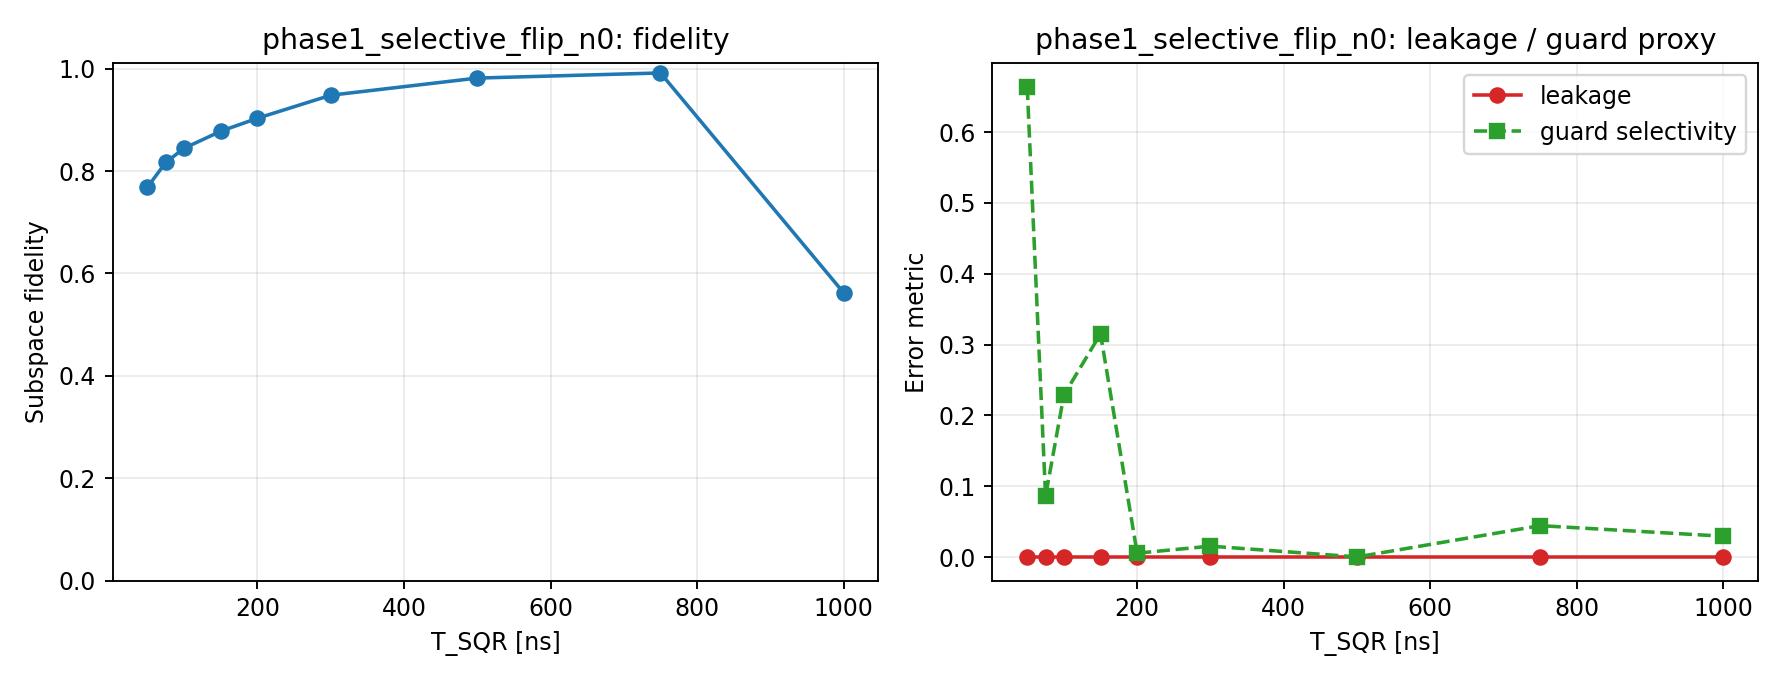

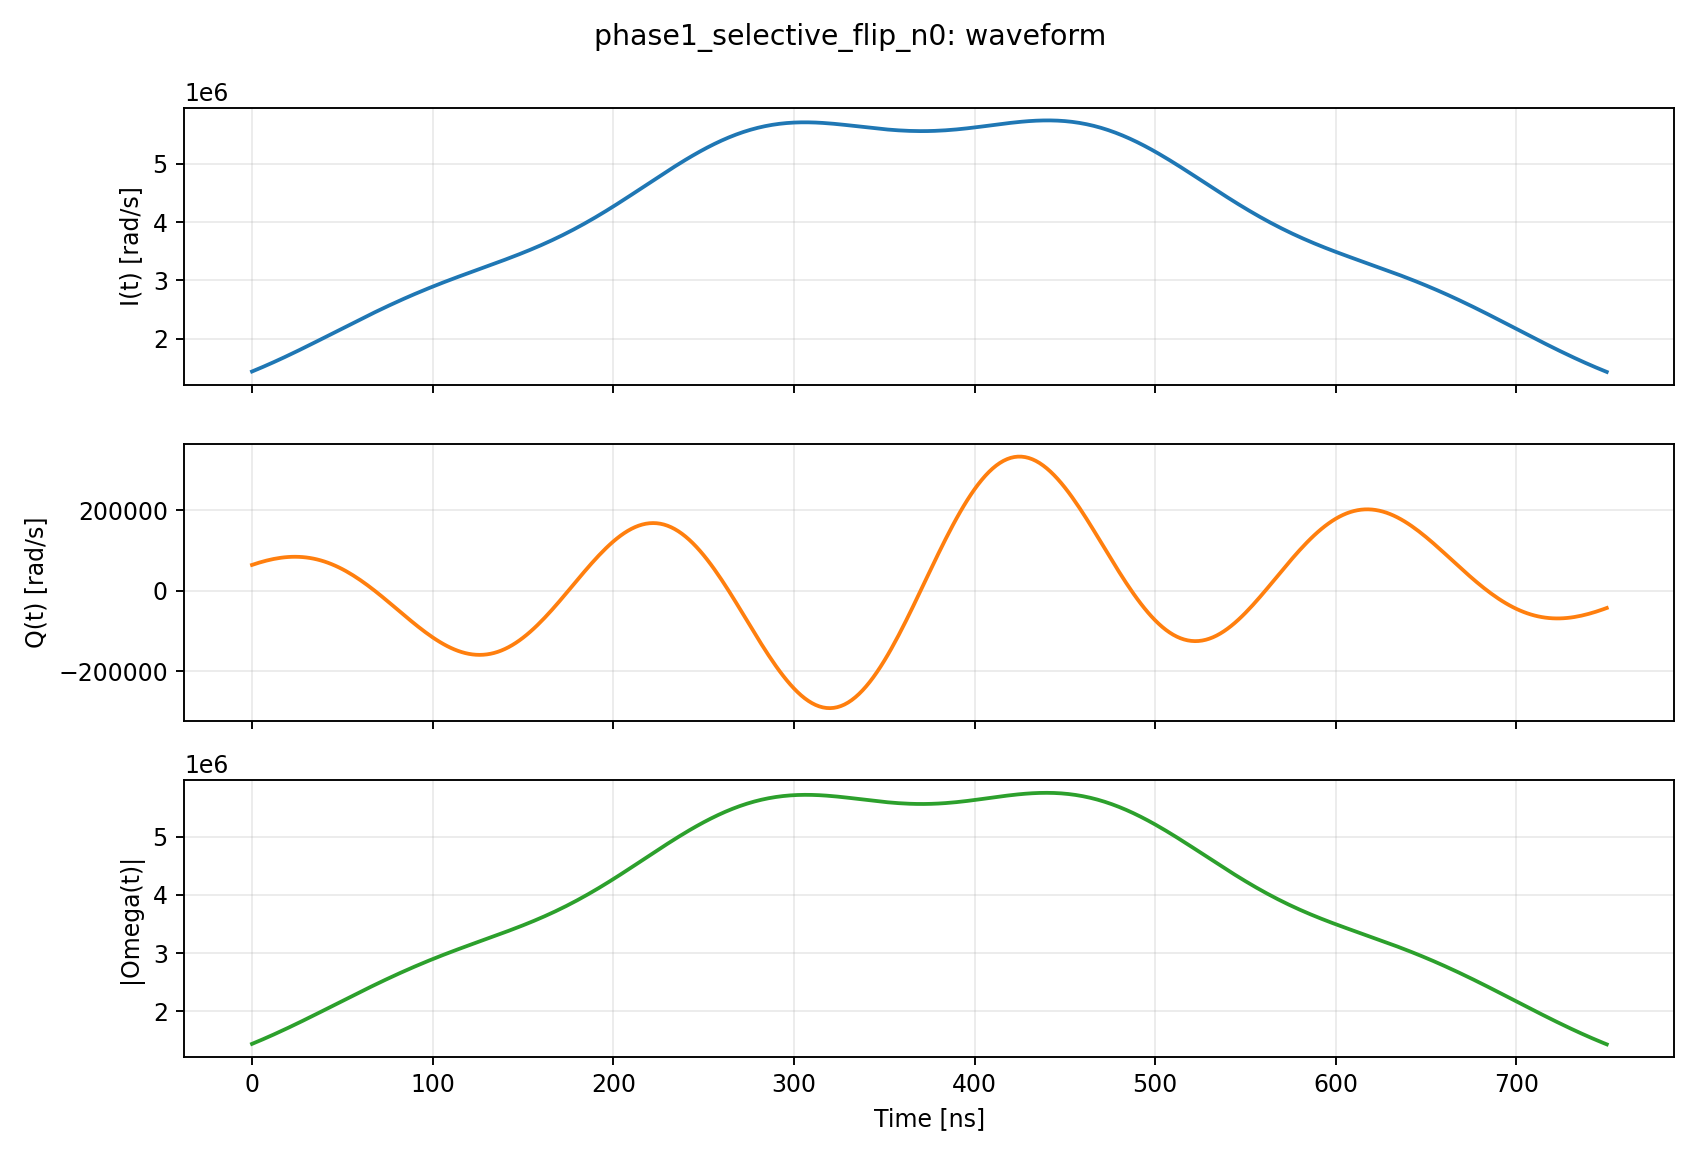

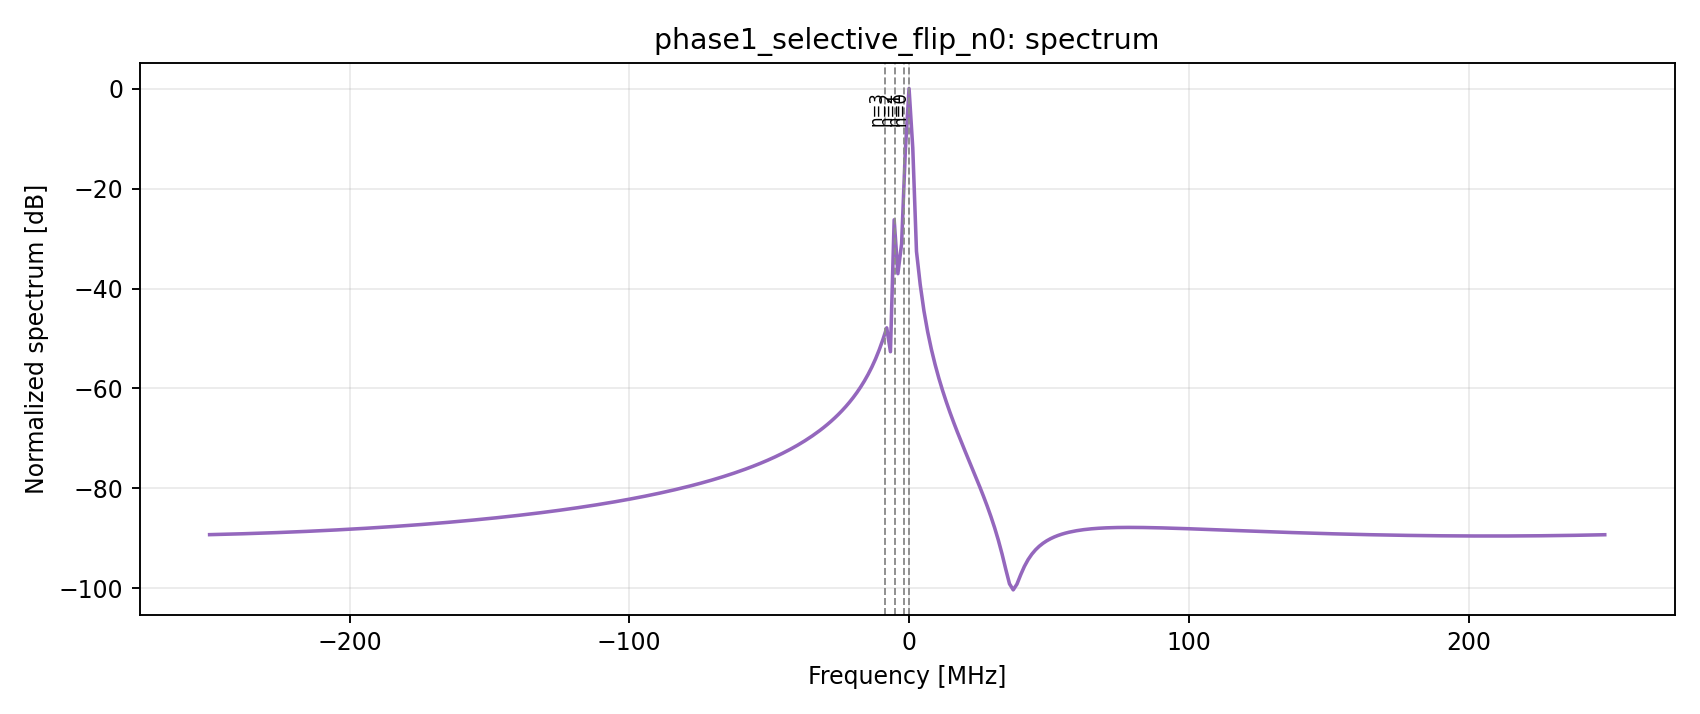

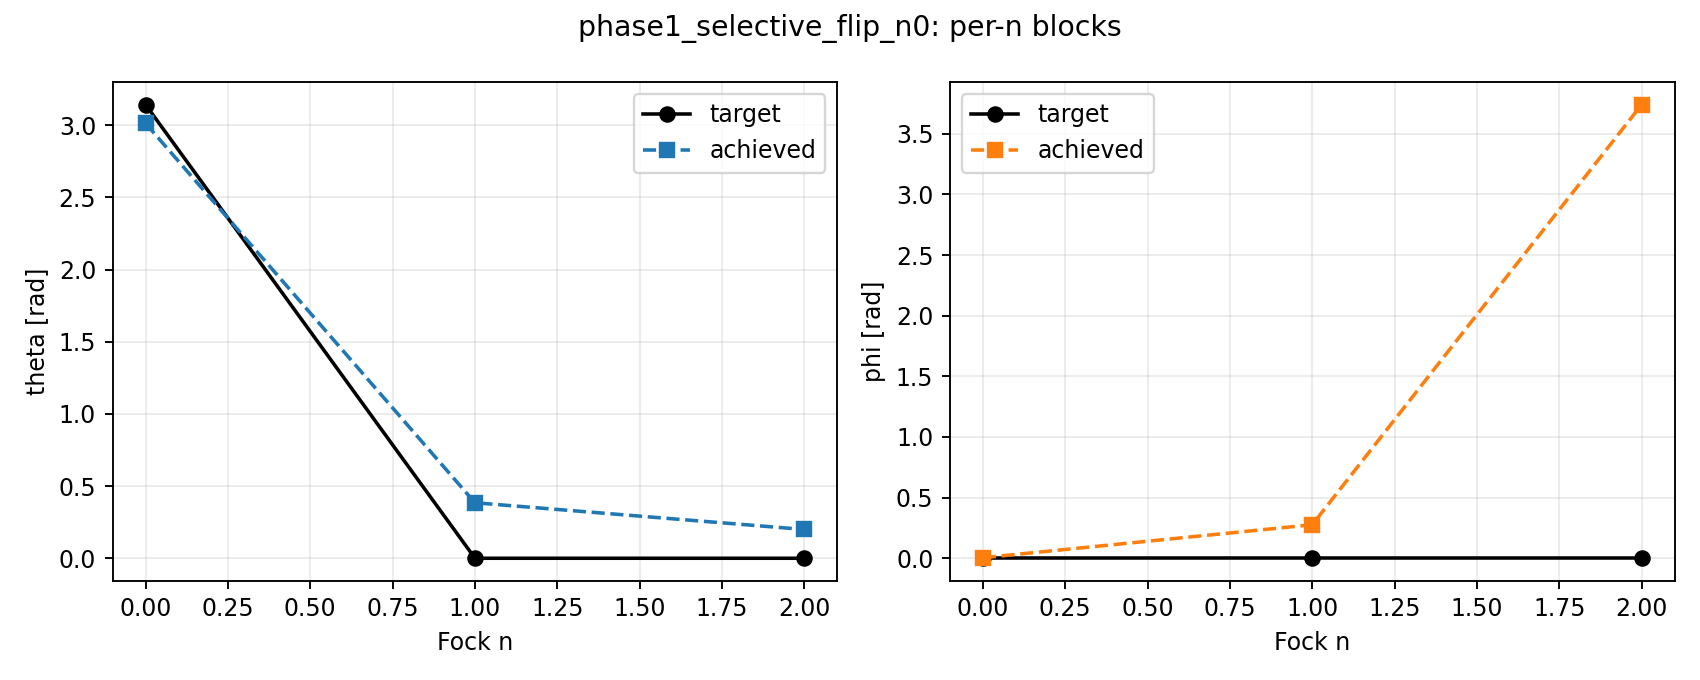

phase2_alternating_flips


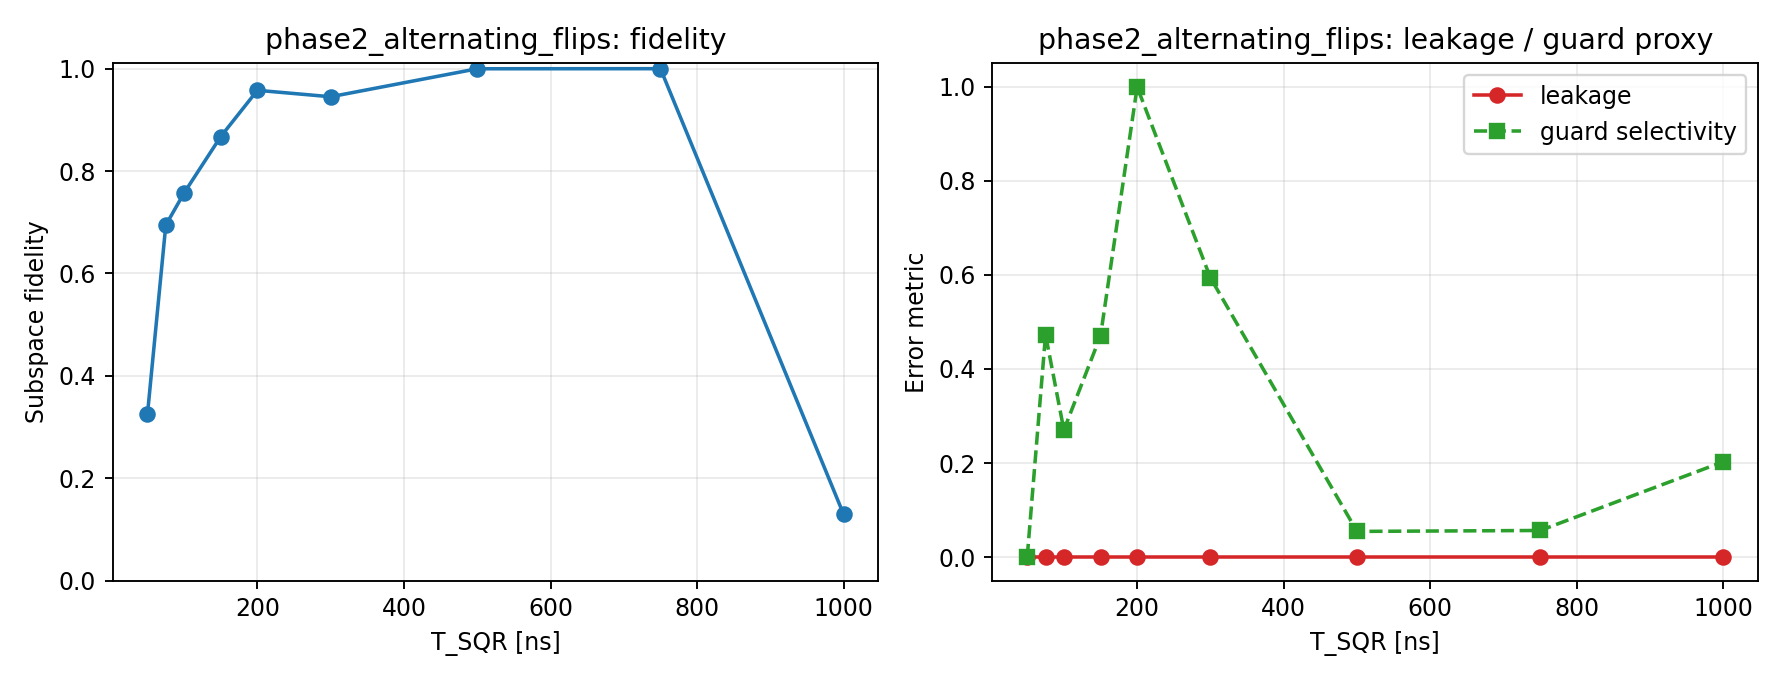

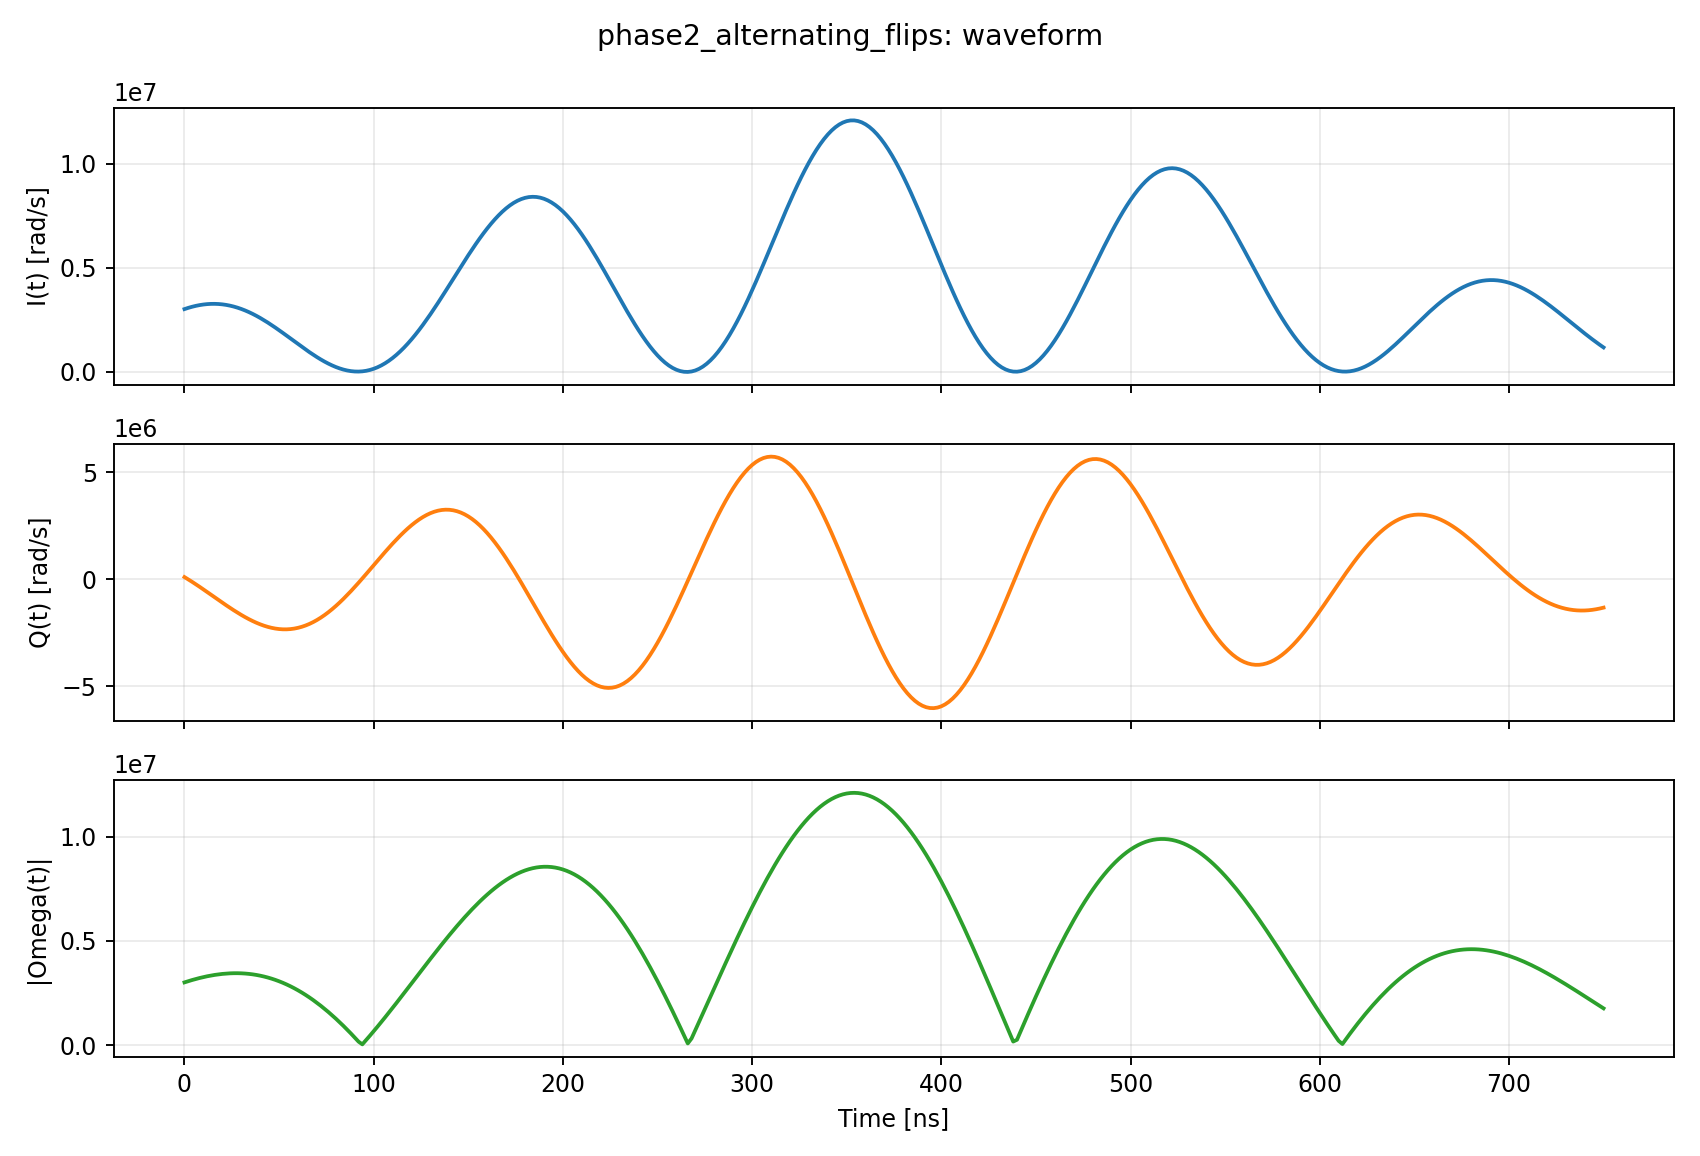

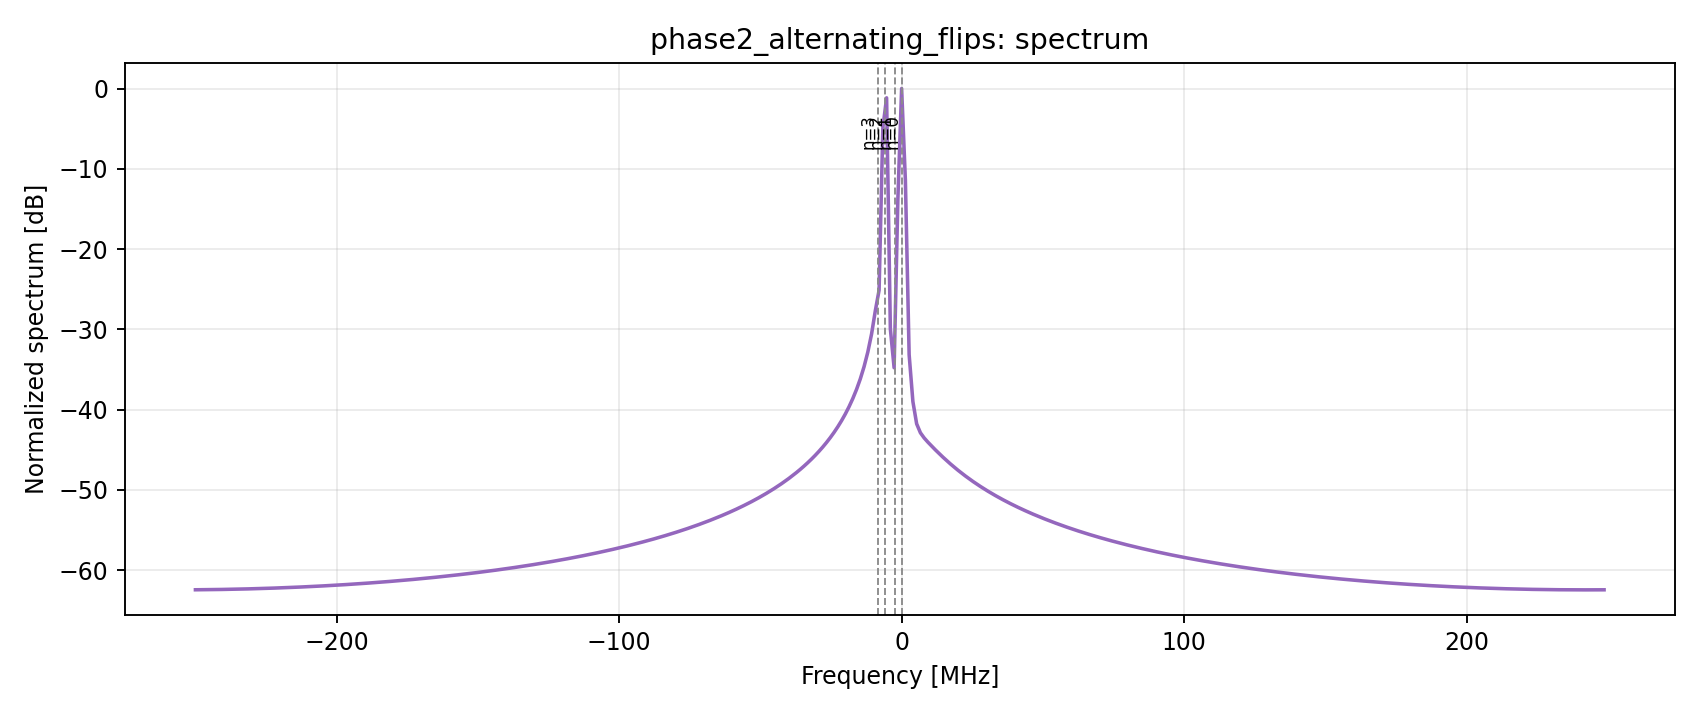

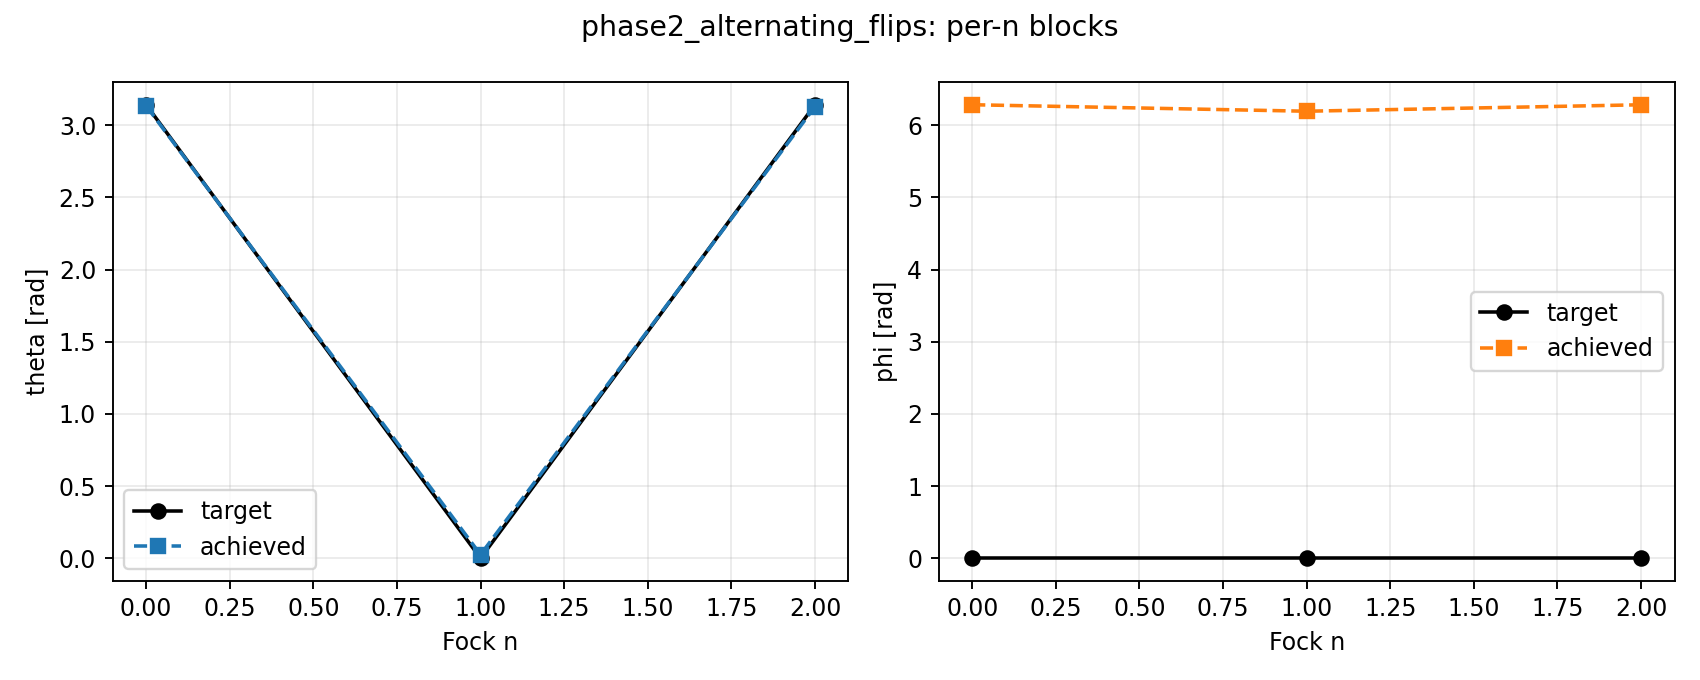

phase2_mixed_angles


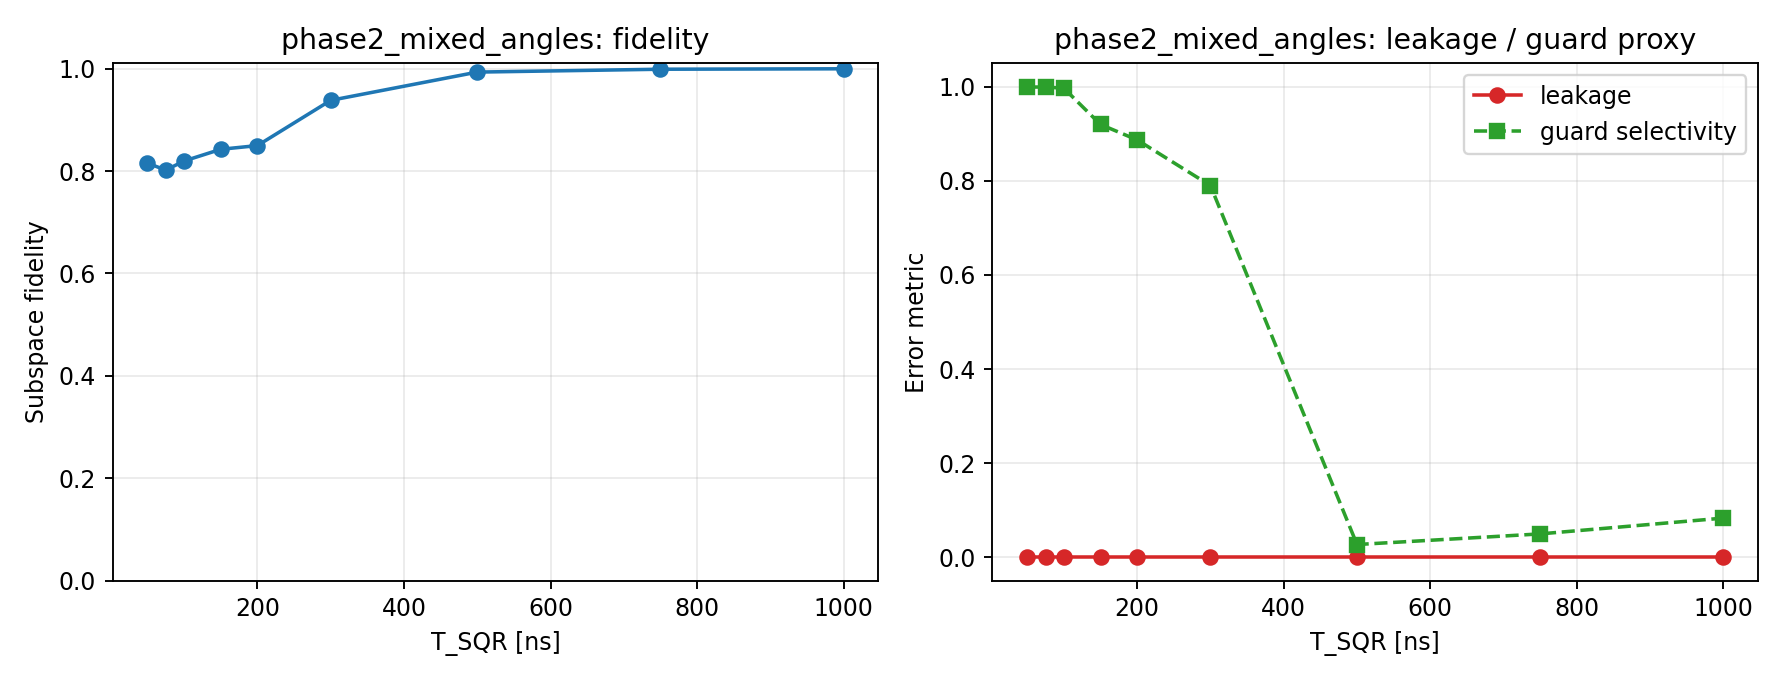

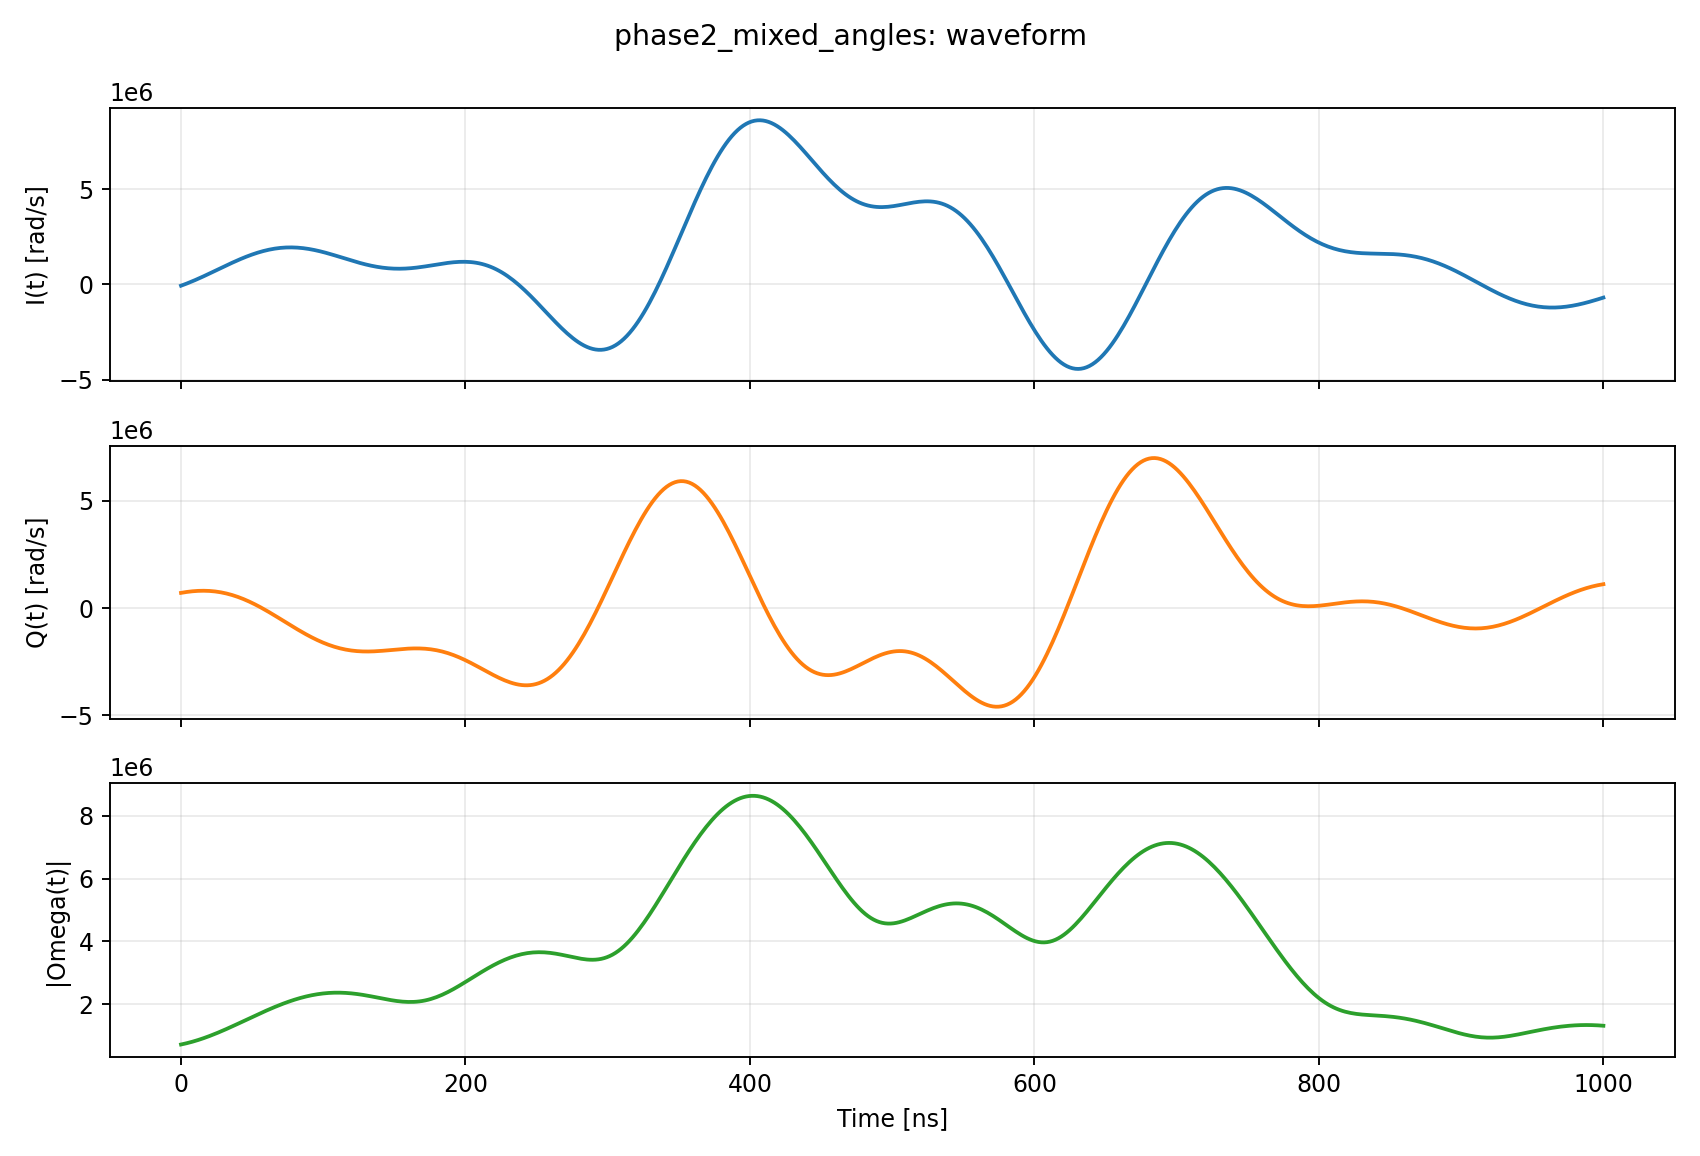

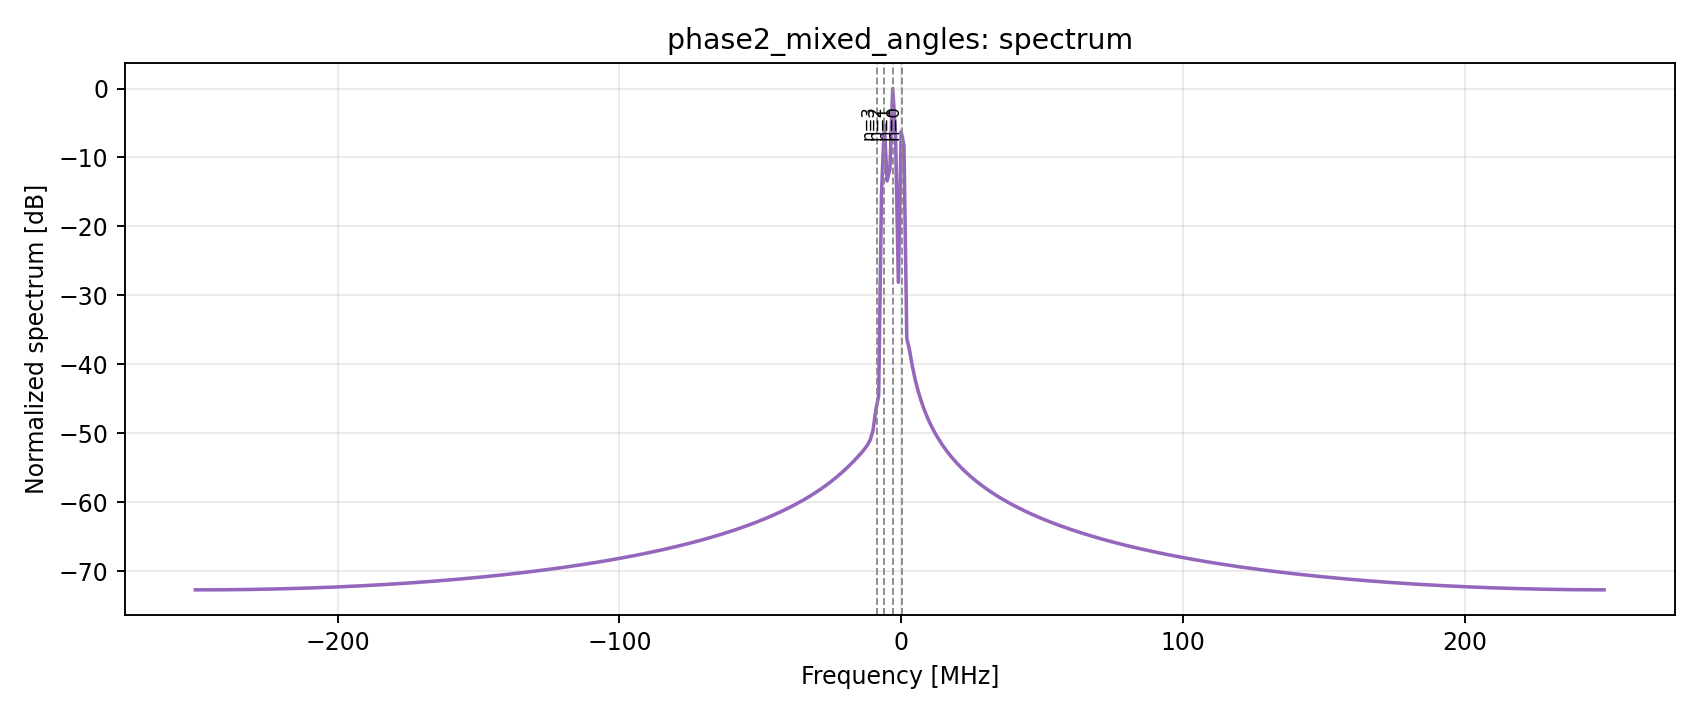

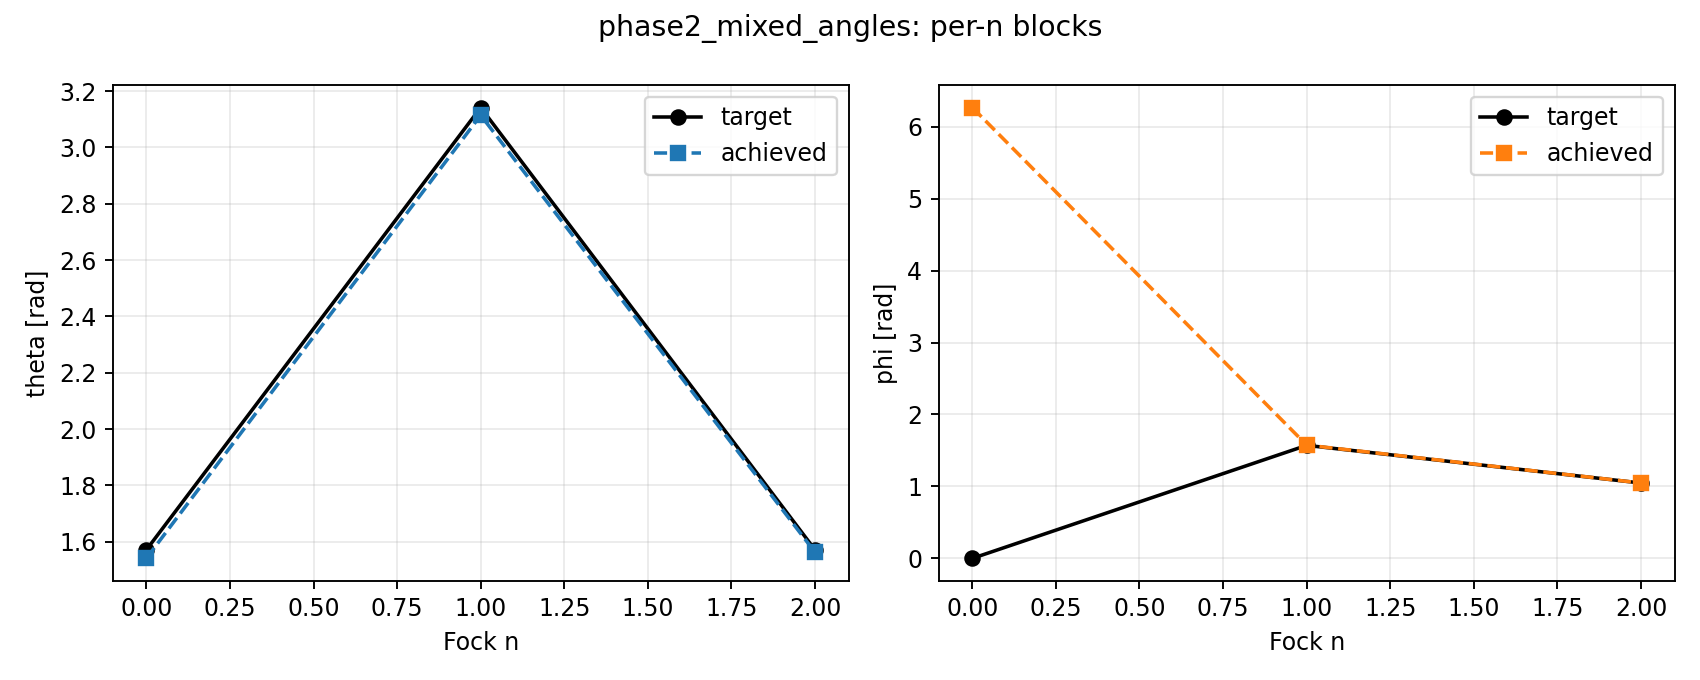

phase2_seeded_random


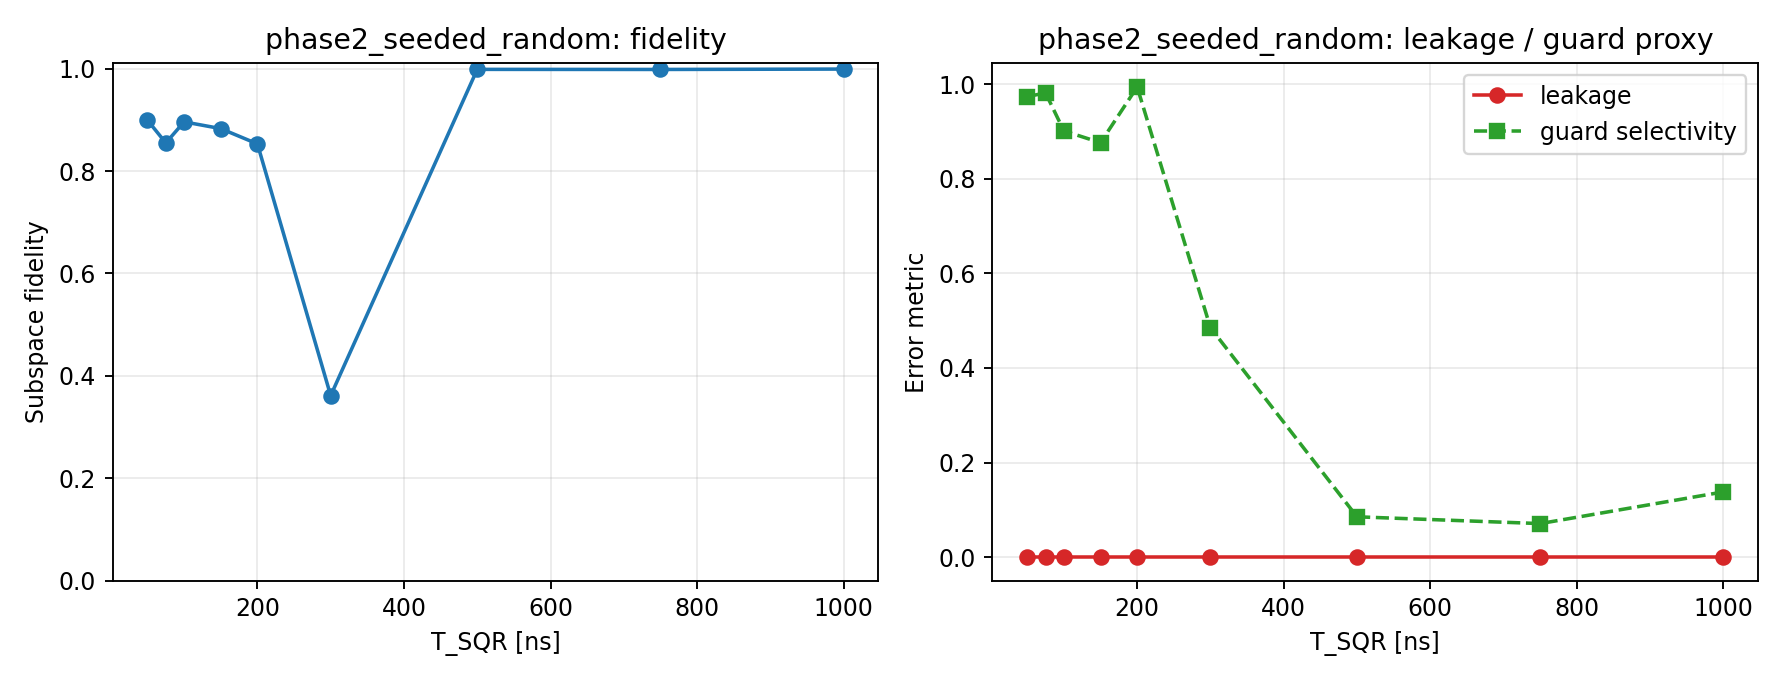

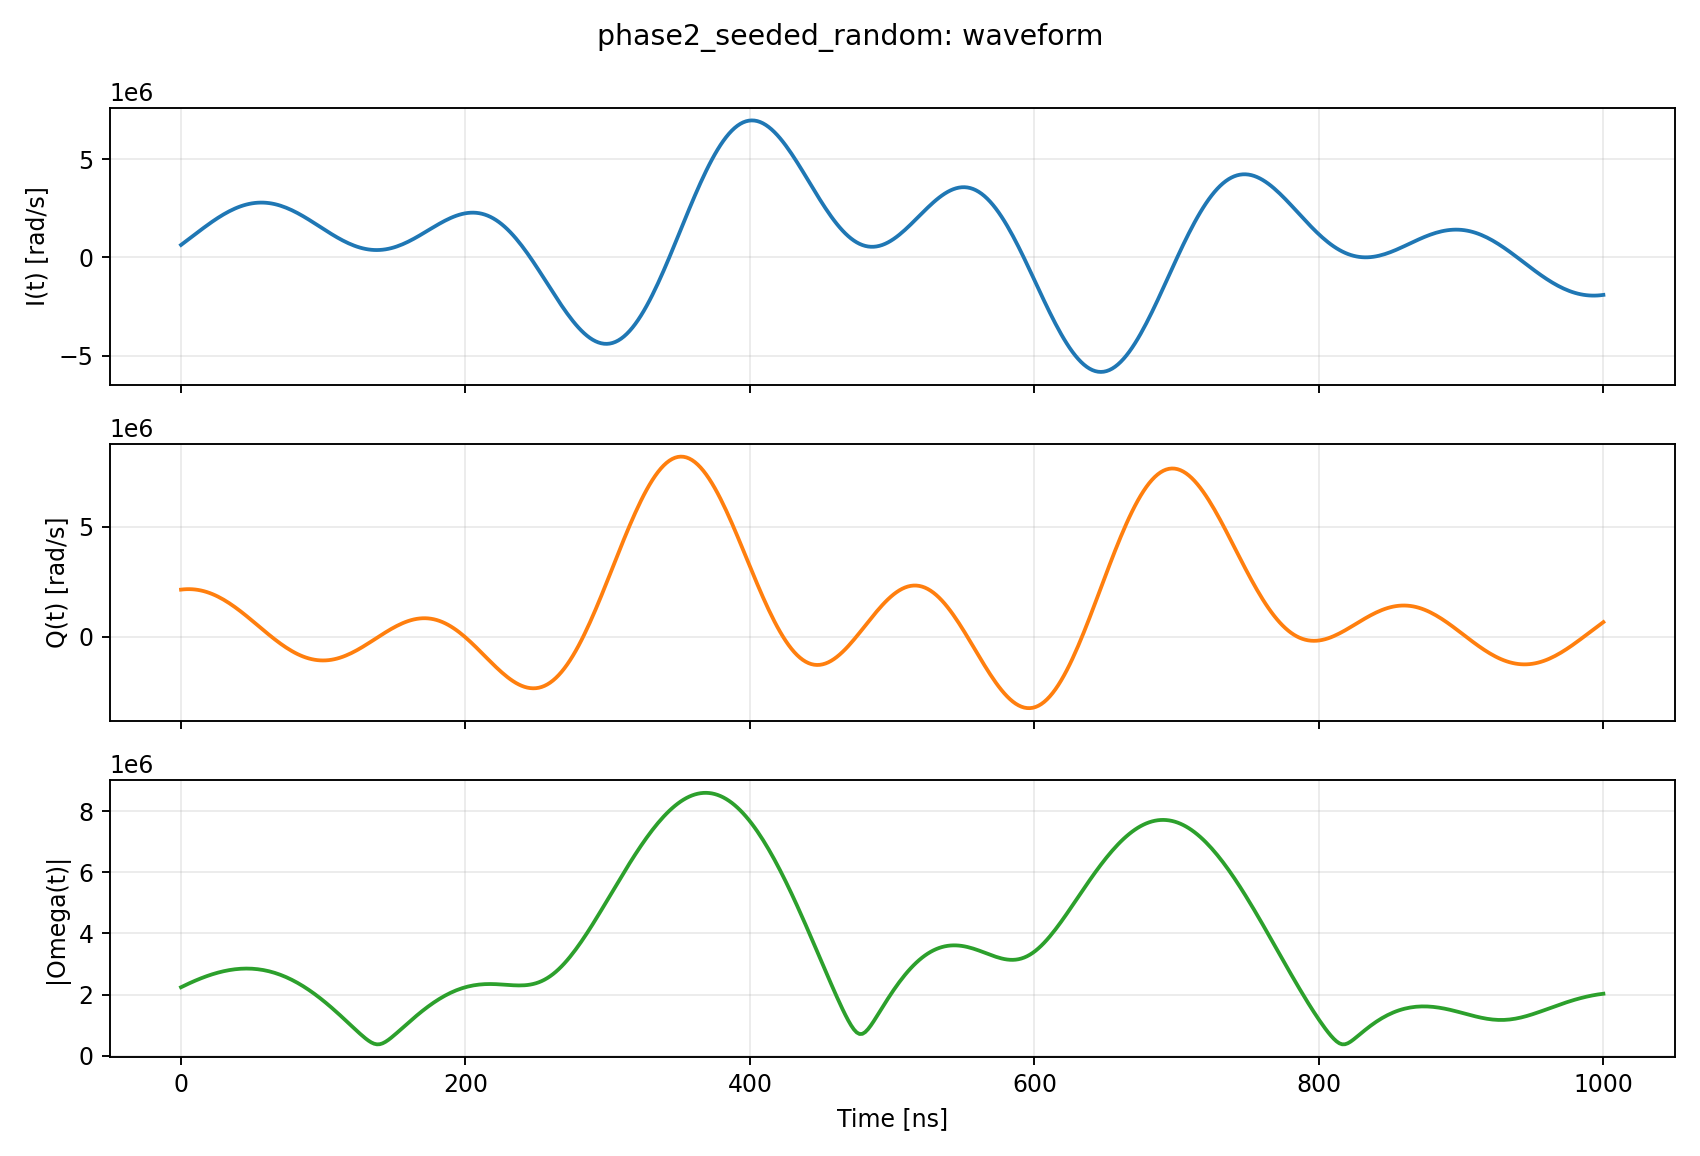

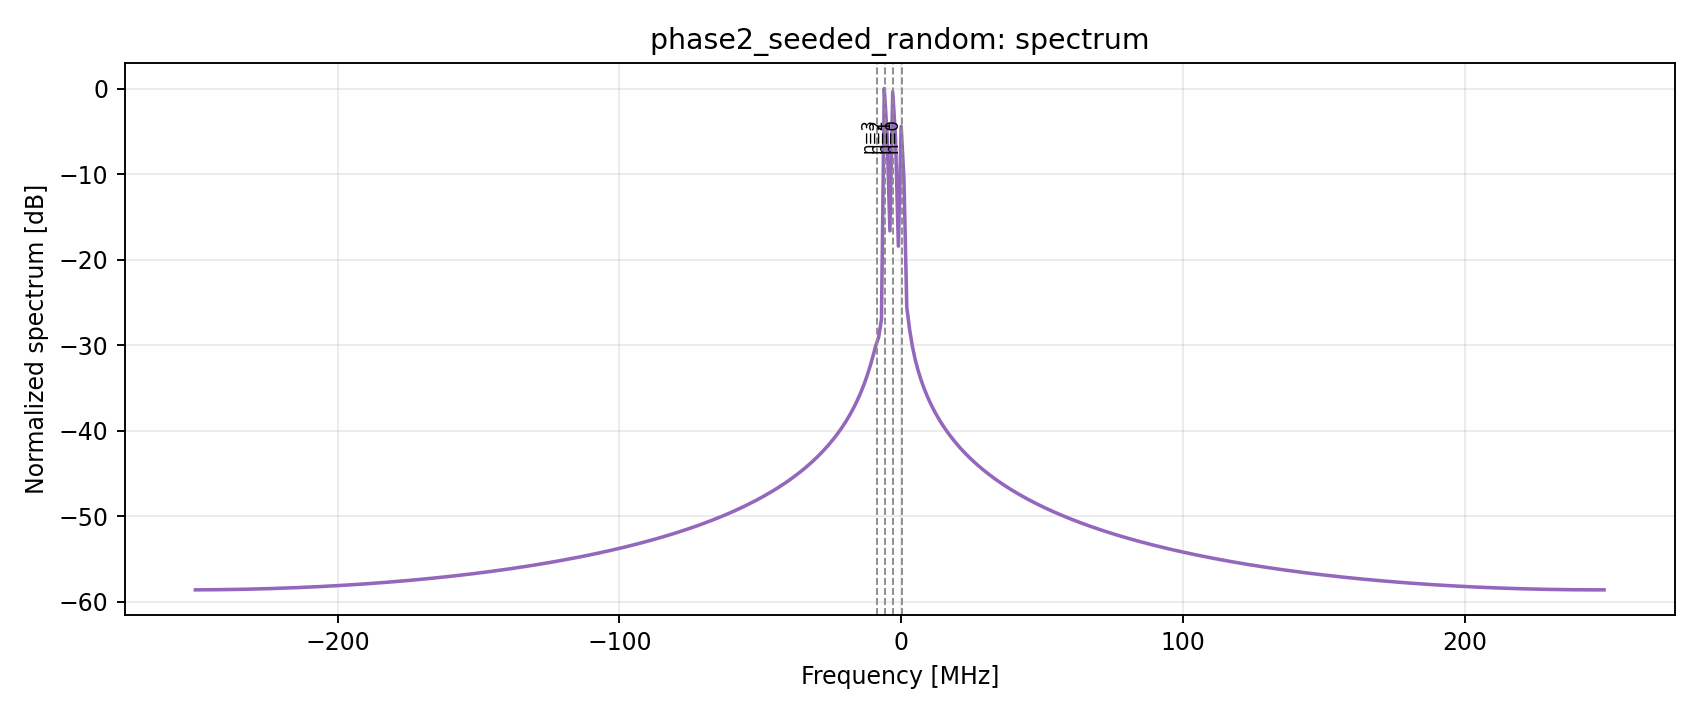

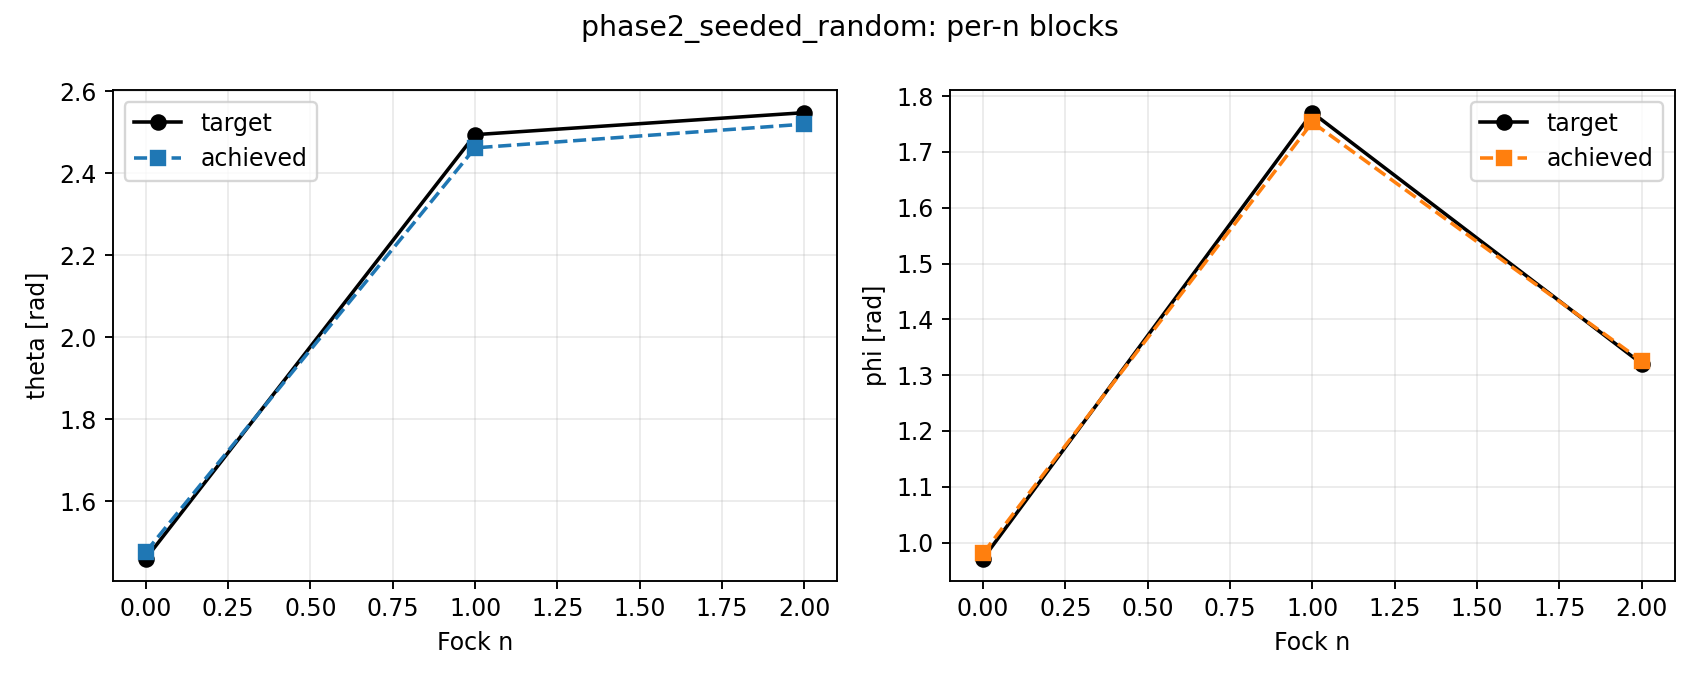

phase2_cluster_like


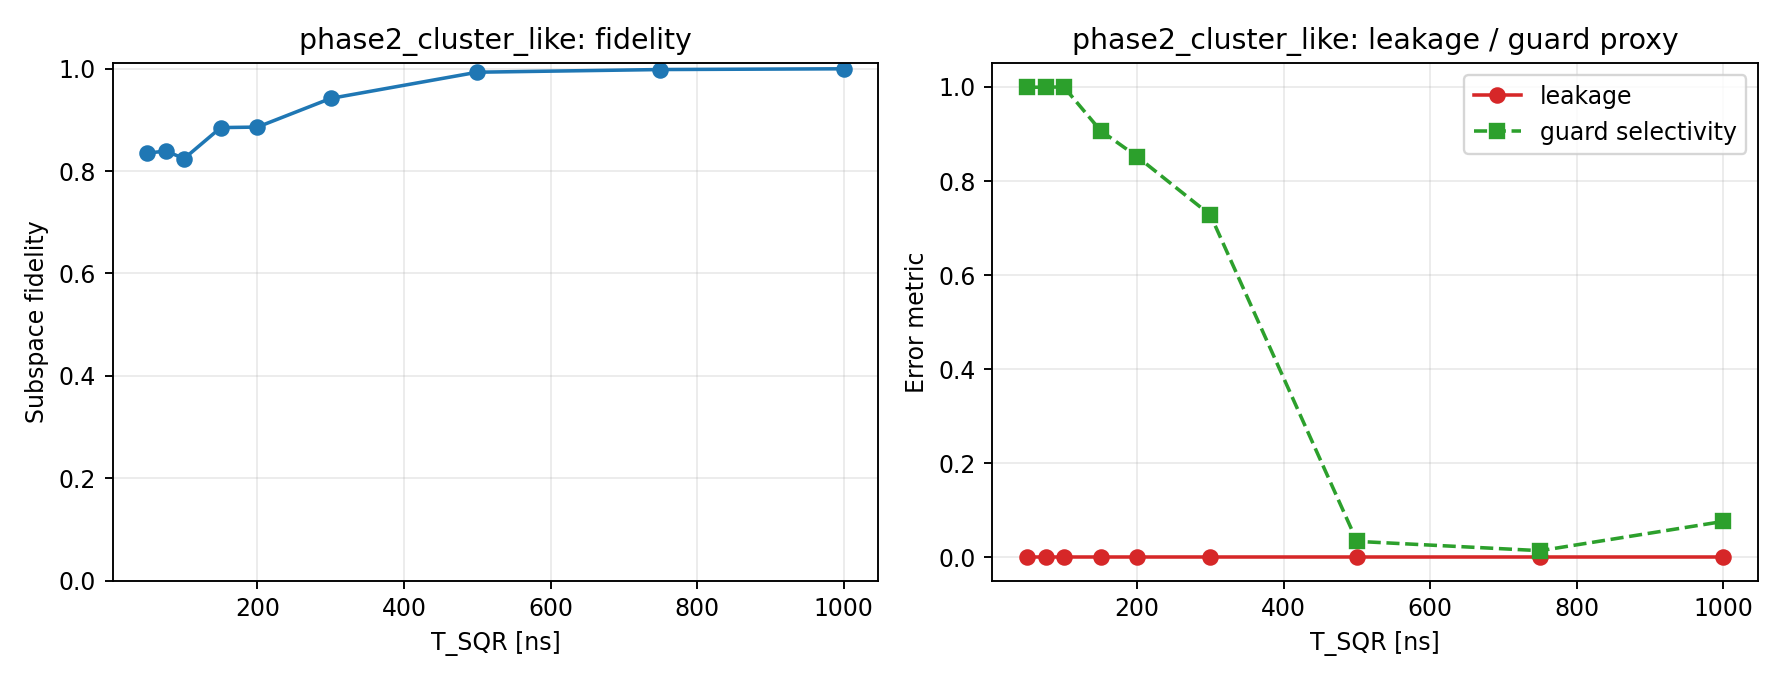

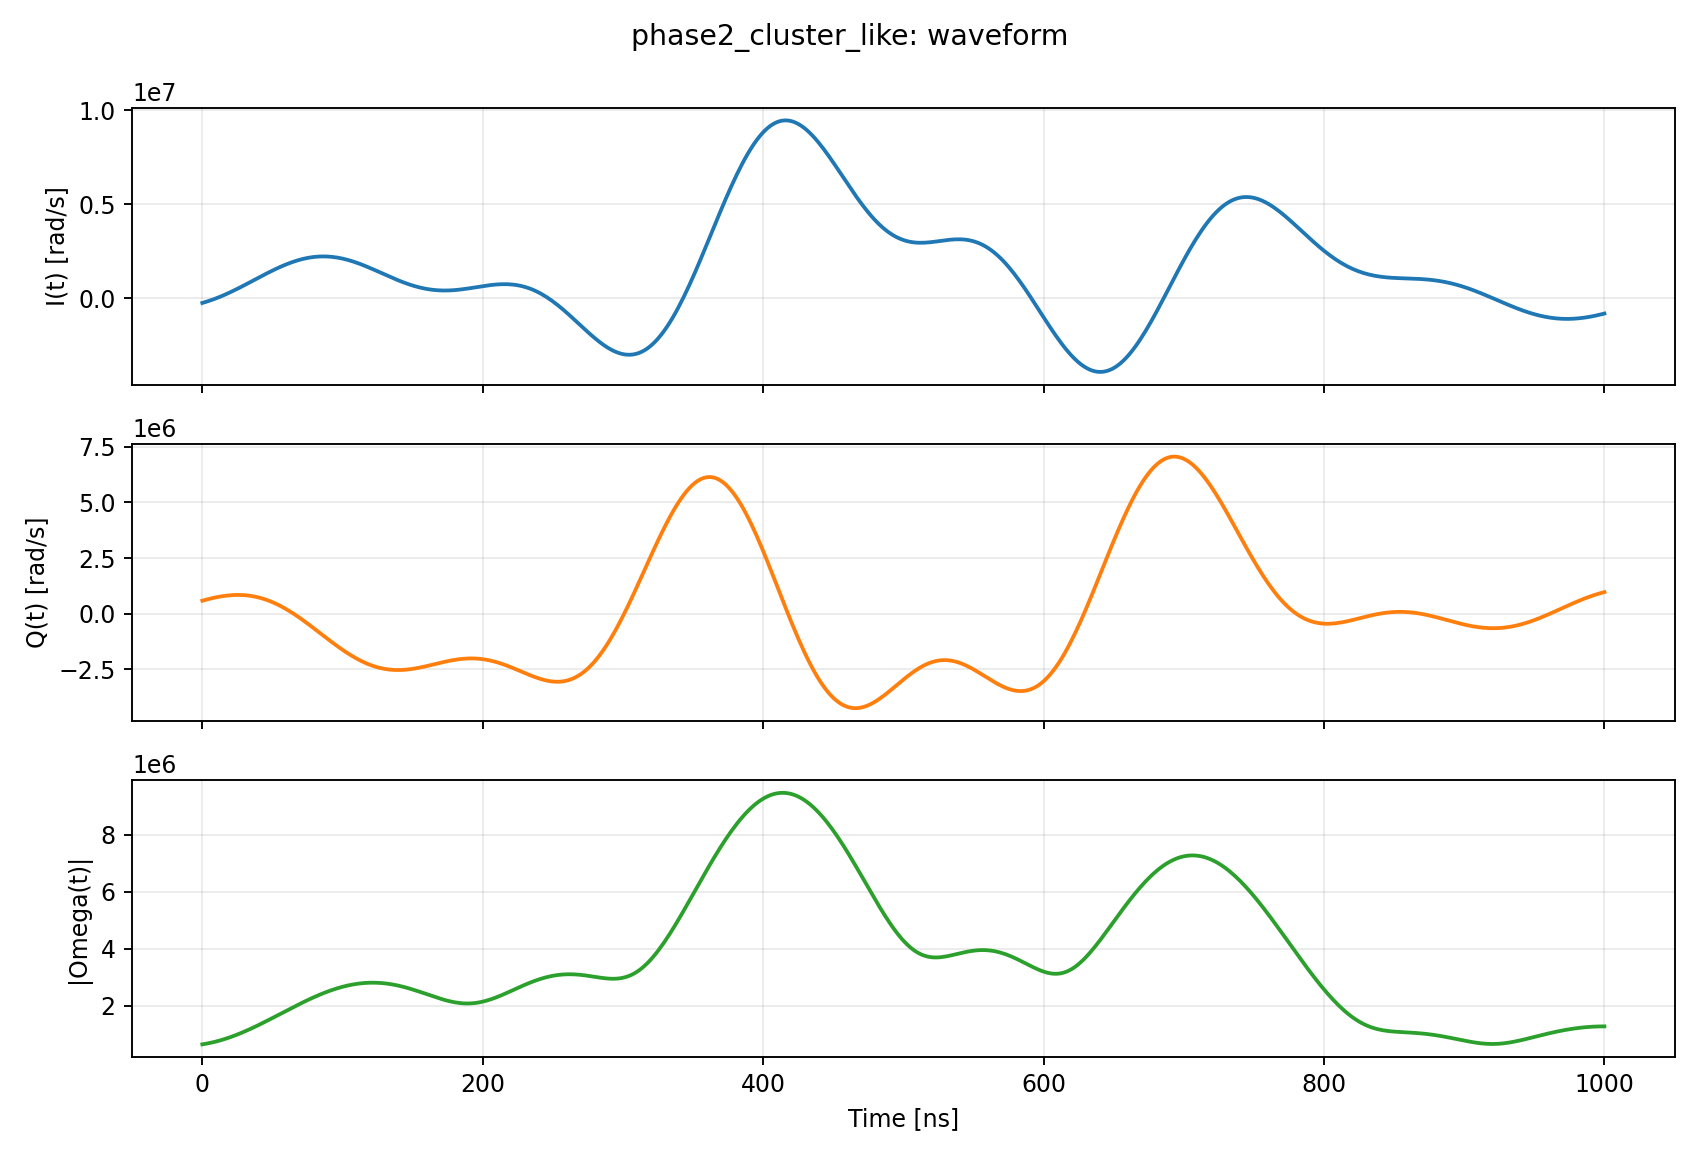

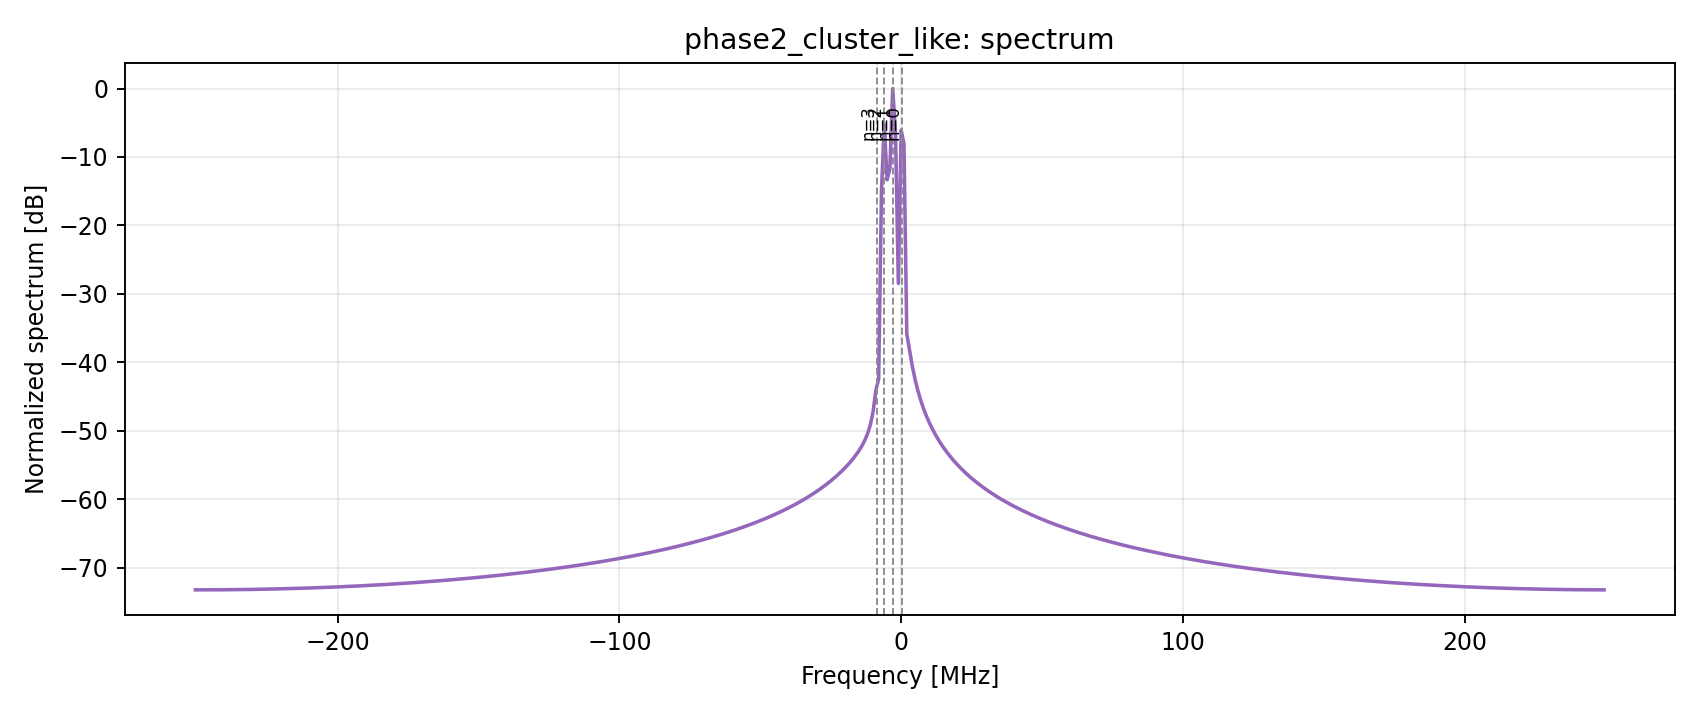

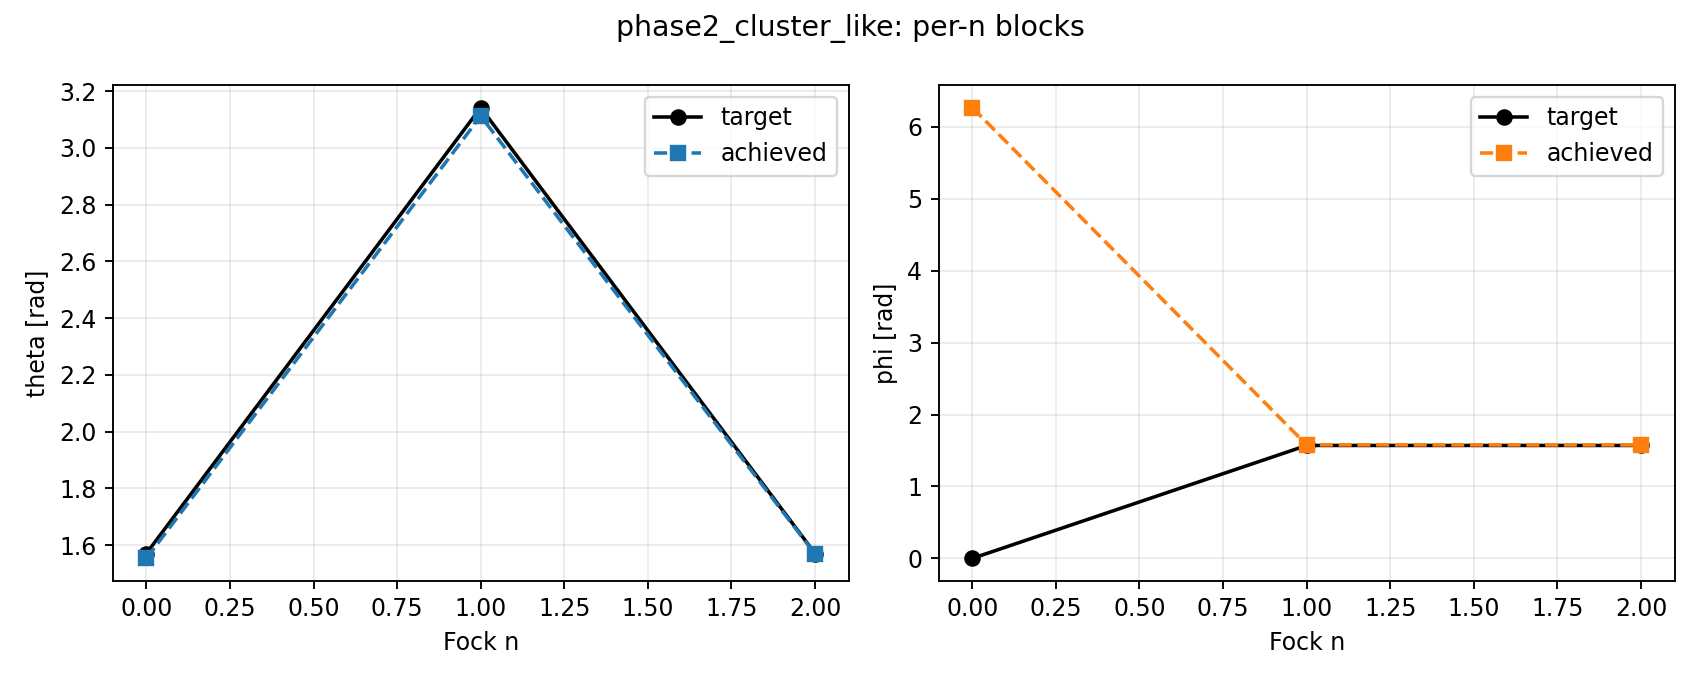

In [9]:
for case in summary['phase1'] + summary['phase2']:
    print(case['case_name'])
    display(Image(filename=case['curve_path']))
    display(Image(filename=case['waveform_path']))
    display(Image(filename=case['spectrum_path']))
    display(Image(filename=case['per_n_path']))


## Fast 16 ns Unconditional Pi Validation


,n_validate,subspace_fidelity,worst_block_fidelity,average_block_fidelity,leakage_average,leakage_worst,amp_rad_s,amp_hz,detuning_hz,sigma_fraction,history_path,waveform_path,spectrum_path
0,1,0.999679,0.998728,0.999358,0.0,0.0,9.817736e+07,1.562541e+07,-64532.544345,0.120000,outputs\analysis\sqr_speedlimit_multitone_gaus...,outputs\analysis\sqr_speedlimit_multitone_gaus...,outputs\analysis\sqr_speedlimit_multitone_gaus...
1,2,0.998934,0.994917,0.997869,0.0,0.0,9.817145e+07,1.562447e+07,-128750.122375,0.120003,outputs\analysis\sqr_speedlimit_multitone_gaus...,outputs\analysis\sqr_speedlimit_multitone_gaus...,outputs\analysis\sqr_speedlimit_multitone_gaus...


n <= 1


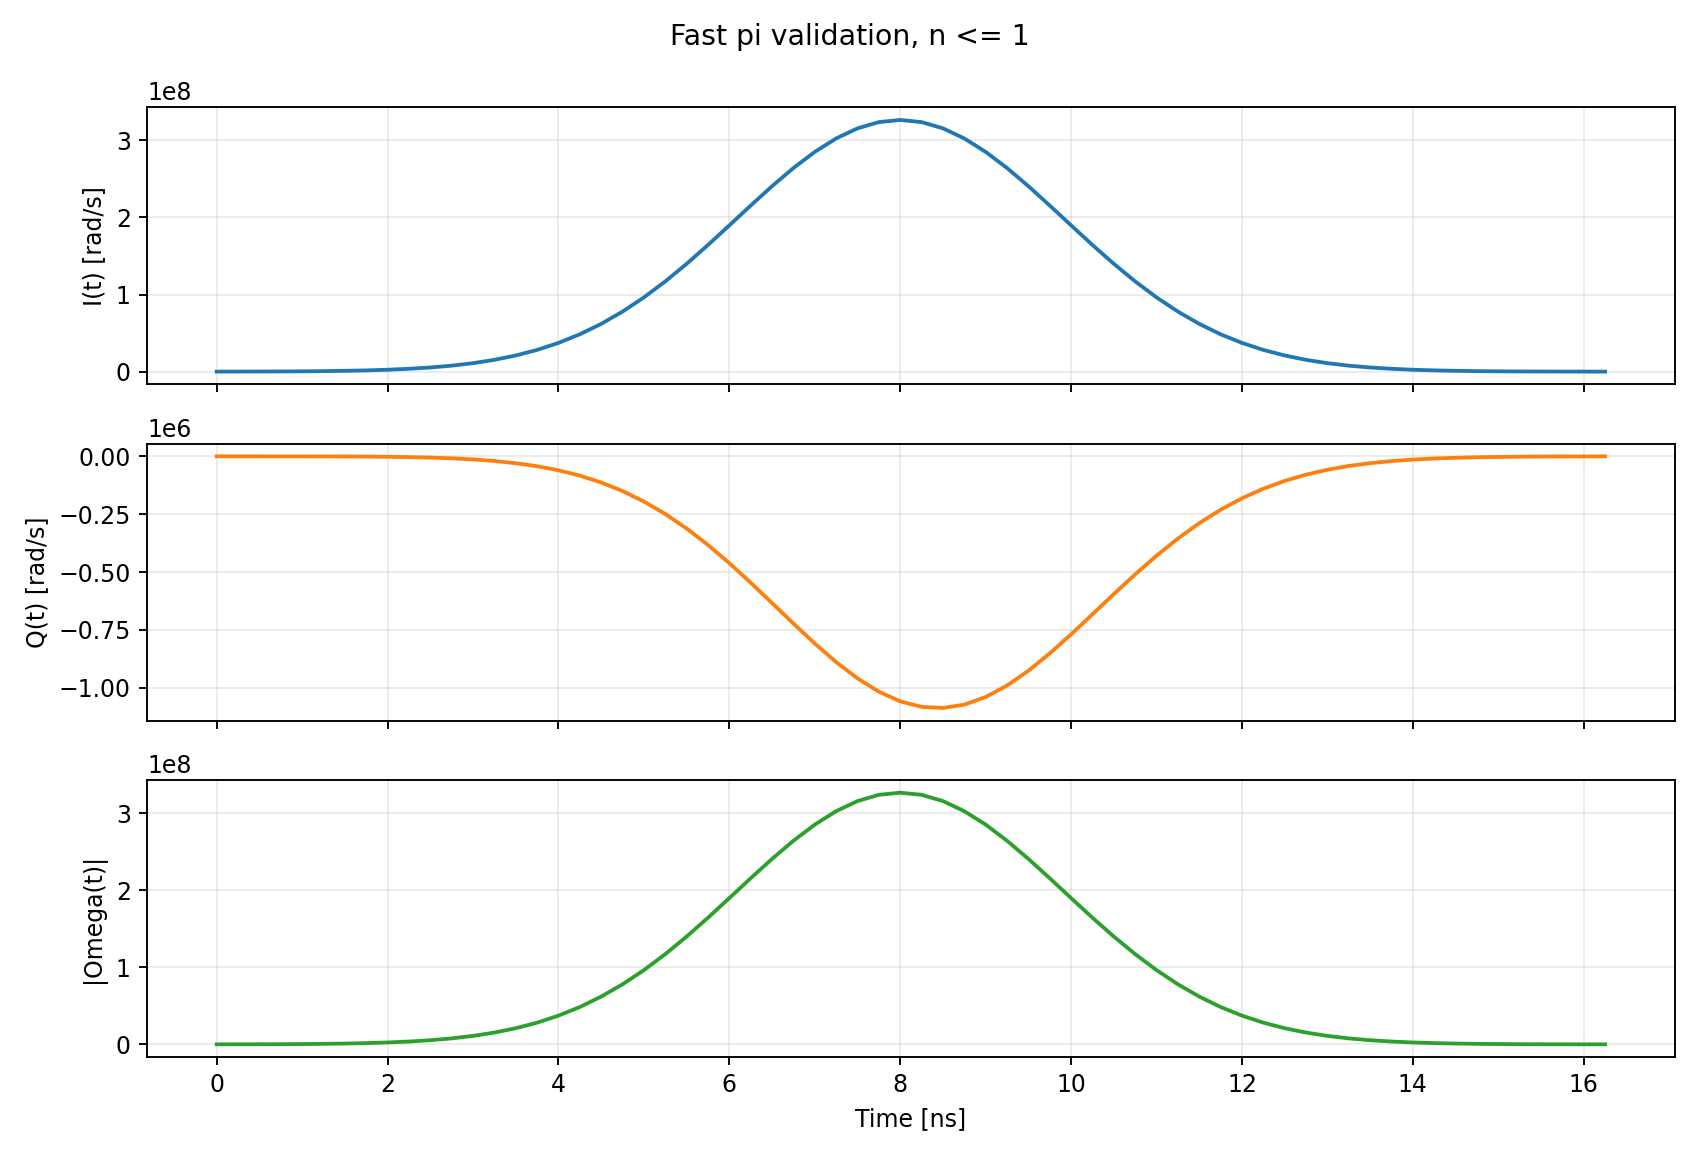

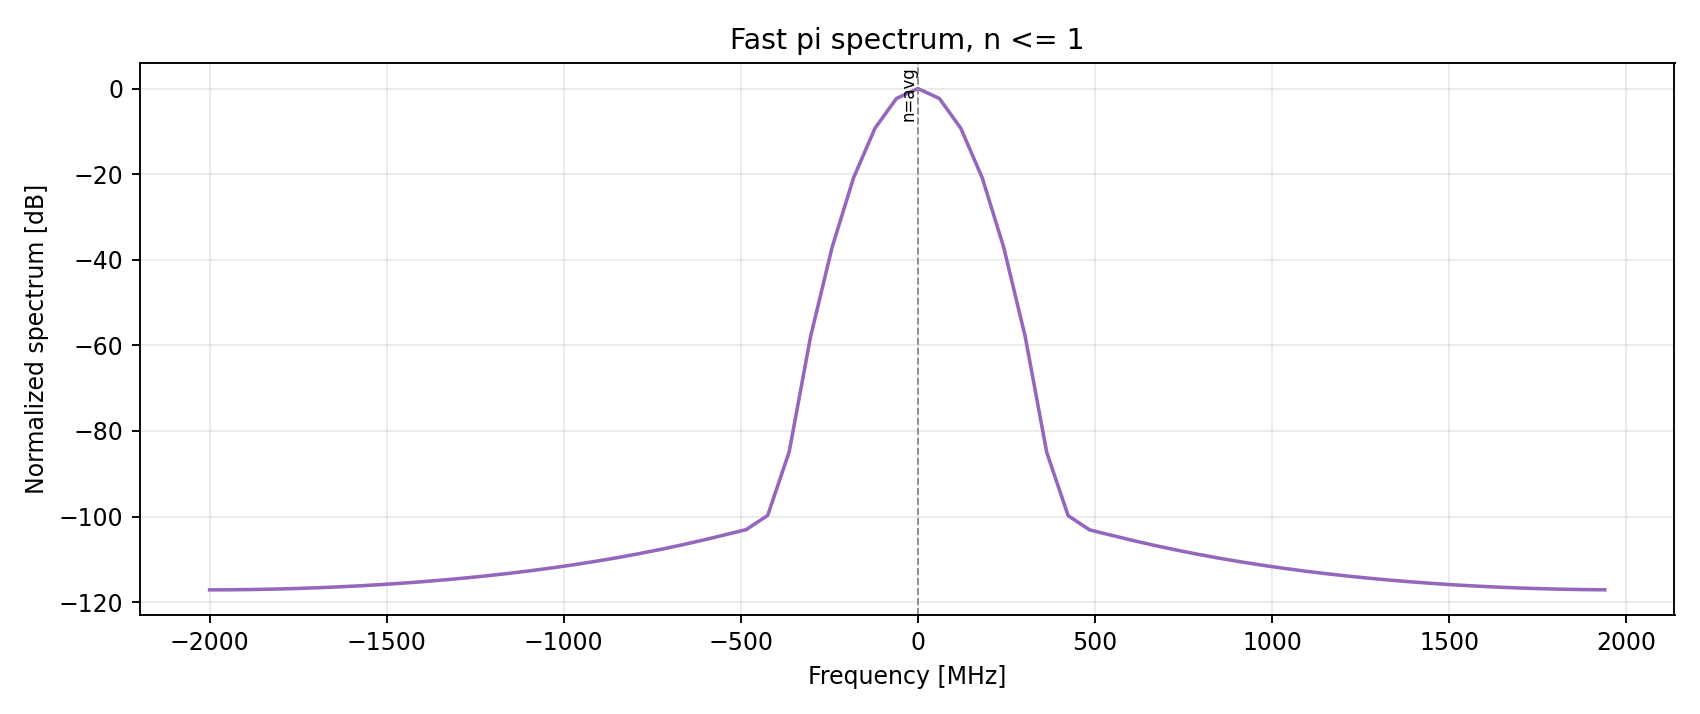

n <= 2


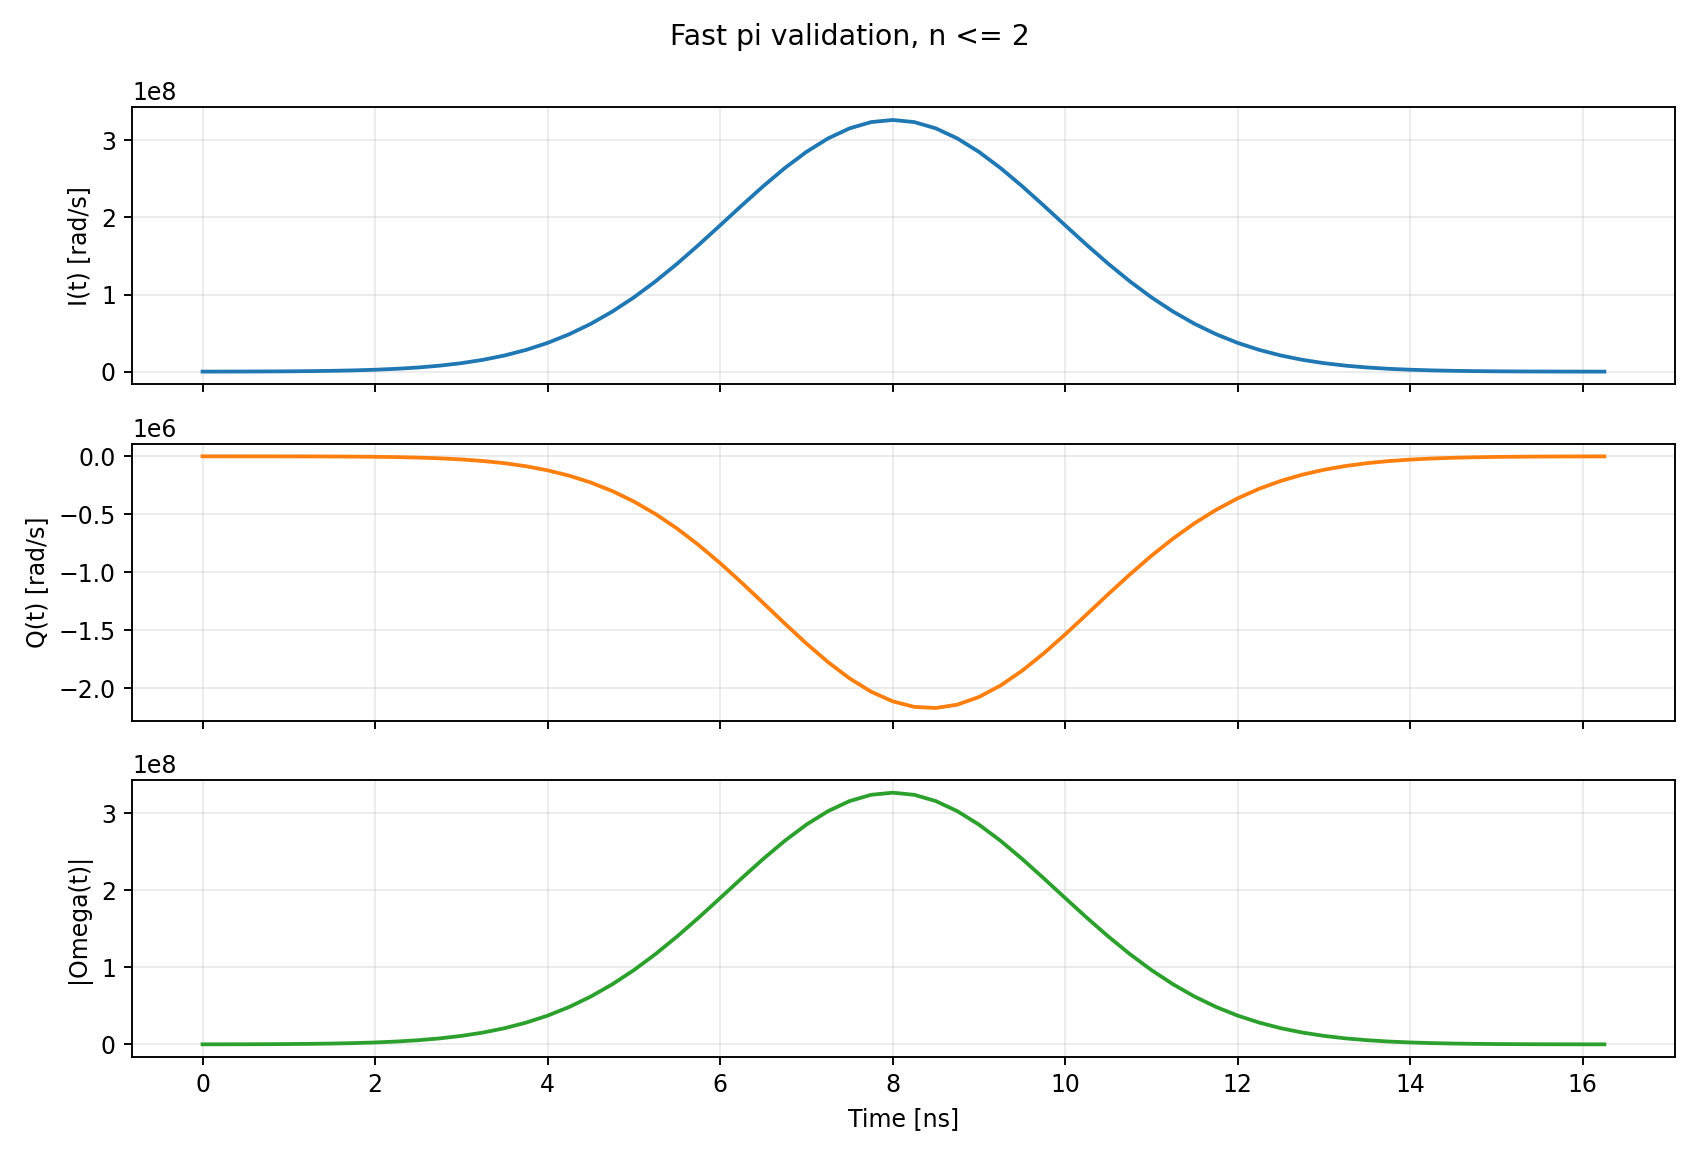

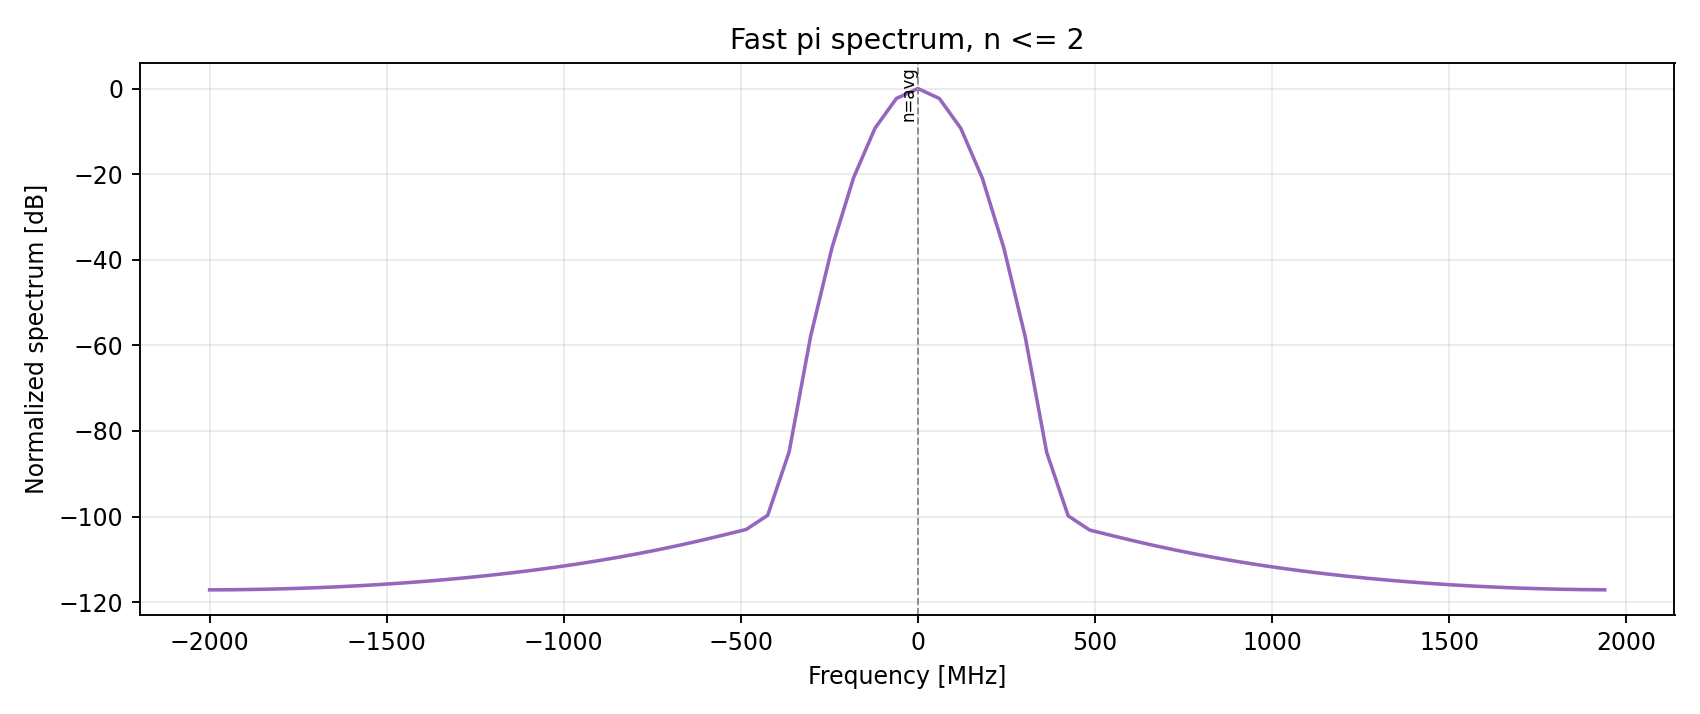

: 

In [ ]:
fast_pi_df = pd.DataFrame(summary['fast_pi']['results'])
display(fast_pi_df)
for row in summary['fast_pi']['results']:
    print(f"n <= {row['n_validate']}")
    display(Image(filename=row['waveform_path']))
    display(Image(filename=row['spectrum_path']))


## Notes

- The main sweep reports subspace-only fidelity on `n <= n_match`.
- Higher Fock levels are intentionally not matched in the objective.
- In this minimal dispersive model the cavity Fock number is conserved, so the `guard_selectivity_error` is the more informative selectivity diagnostic than literal leakage.
